## 1. Imports & global settings


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets
from ipywidgets import interactive_output, VBox, HBox
from IPython.display import display

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True


### 1.1 Analysis parameters

These settings are applied to **all** parquets.


In [2]:
# Segmentation and preprocessing parameters (applied to all parquets)
GAP_THRESHOLD_SECONDS = 3600   # split segment if gap > 1 hour
MIN_POINTS_PER_SEGMENT = 100   # minimum rows per segment
EMA_ALPHA = 0.1                # smoothing factor (0 < alpha <= 1)


## 2. Signal mapping

Mapping between `signal_id` and human-readable signal names and metadata.


In [3]:
mapping = {
    'signal_id': [8890,9620,9619,11247,11333,11331,16769,15454,15453,16679,14156,14154,
                  26499,30654,30653,29296,29388,29386,16796,24141,24140,25120,25207,25205,
                  18263,19318,19317,21058,21145,21143],
    'measurement_unit': ['MW','', '', '%','bar','bar','MW','','','%','bar','bar',
                         'MW','','','%','bar','bar','MW','','','%','bar','bar',
                         'MW','','','%','bar','bar'],
    'type_id': ['measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)',
                'measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)',
                'measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)',
                'measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)',
                'measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)'],
    'plant': ['KSL']*30,
    'stage': ['Mapragg','Mapragg','Mapragg','Mapragg','Mapragg','Mapragg',
              'Sarelli','Sarelli','Sarelli','Sarelli','Sarelli','Sarelli',
              'Mapragg','Mapragg','Mapragg','Mapragg','Mapragg','Mapragg',
              'Sarelli','Sarelli','Sarelli','Sarelli','Sarelli','Sarelli',
              'Mapragg','Mapragg','Mapragg','Mapragg','Mapragg','Mapragg'],
    'machine_group': ['MG1','MG1','MG1','MG1','MG1','MG1',
                      'MG1','MG1','MG1','MG1','MG1','MG1',
                      'MG2','MG2','MG2','MG2','MG2','MG2',
                      'MG2','MG2','MG2','MG2','MG2','MG2',
                      'MG3','MG3','MG3','MG3','MG3','MG3'],
    'signal_name': ['active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream',
                    'active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream',
                    'active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream',
                    'active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream',
                    'active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream'],
    'description': [
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
    ]
}

df_mapping = pd.DataFrame(mapping)
df_mapping.head()

,signal_id,measurement_unit,type_id,plant,stage,machine_group,signal_name,description
0,8890,MW,measurement (analog),KSL,Mapragg,MG1,active_power,Active power measurement
1,9620,,Bool,KSL,Mapragg,MG1,ball_valve_closed,Ball valve position rotating body closed (true...
2,9619,,Bool,KSL,Mapragg,MG1,ball_valve_open,Ball valve position rotating body open (true i...
3,11247,%,measurement (analog),KSL,Mapragg,MG1,guide_vane_position,Guide vane position measurement
4,11333,bar,measurement (analog),KSL,Mapragg,MG1,water_pressure_downstream,water pressure downstream of the turbine


## 3. Helper functions

Functions for gap analysis, segmentation, extraction, smoothing and correlation.


In [4]:
def analyze_gaps(df, time_col='ts_sec'):
    """Print basic gap statistics for a given dataframe."""
    arr = np.sort(df[time_col].unique())
    if len(arr) < 2:
        print('Not enough points for gap analysis.')
        return
    diffs = np.diff(arr)
    print('Gap analysis:')
    print(f'  Min gap: {diffs.min():.2f} s')
    print(f'  Max gap: {diffs.max():.2f} s')
    print(f'  Mean gap: {diffs.mean():.2f} s')
    print(f'  Median gap: {np.median(diffs):.2f} s')
    print(f'  95th percentile: {np.percentile(diffs, 95):.2f} s')
    print(f'  99th percentile: {np.percentile(diffs, 99):.2f} s')


In [5]:
def create_synchronized_segments(df, gap_threshold_seconds=3600, min_points=1):
    """Split dataframe into segments based on gaps in `ts_sec`.

    Parameters
    ----------
    df : DataFrame with column 'ts_sec'
    gap_threshold_seconds : float, gap > threshold triggers a new segment
    min_points : int, minimum number of rows to keep a segment
    """
    df_sorted = df.sort_values('ts_sec').reset_index(drop=True)
    all_ts = np.sort(df_sorted['ts_sec'].unique())
    if len(all_ts) == 0:
        return []
    if len(all_ts) == 1:
        return [df_sorted]

    diffs = np.diff(all_ts)
    gap_indices = np.where(diffs > gap_threshold_seconds)[0]

    segments = []
    start_idx = 0

    def add_segment(seg):
        if len(seg) >= min_points:
            segments.append(seg)

    for gap_idx in gap_indices:
        start_time = all_ts[start_idx]
        end_time = all_ts[gap_idx]
        seg = df_sorted[(df_sorted['ts_sec'] >= start_time) &
                        (df_sorted['ts_sec'] <= end_time)].copy()
        add_segment(seg)
        start_idx = gap_idx + 1

    # final segment
    start_time = all_ts[start_idx]
    end_time = all_ts[-1]
    seg = df_sorted[(df_sorted['ts_sec'] >= start_time) &
                    (df_sorted['ts_sec'] <= end_time)].copy()
    add_segment(seg)
    return segments


In [6]:
def extract_and_normalize(segments, signal_name):
    """Extract given signal from each segment and normalize time so t0 = 0.

    Returns a list of dataframes with an extra column 't0_sec'.
    """
    result = []
    for seg in segments:
        sub = seg[seg['signal_name'] == signal_name].copy()
        if not sub.empty:
            segment_start = seg['ts_sec'].min()
            sub['t0_sec'] = sub['ts_sec'] - segment_start

            result.append(sub)
    return result


In [7]:
def get_sampling_rate(df_signal):
    """Estimate sampling rate (Hz) and average interval (s) for a signal segment."""
    if len(df_signal) < 2:
        return None, None
    df_signal = df_signal.sort_values('ts_sec')
    time_diff = np.diff(df_signal['ts_sec'].values)
    avg_interval = np.mean(time_diff)
    sampling_rate = 1.0 / avg_interval if avg_interval != 0 else None
    return sampling_rate, avg_interval


In [8]:
def apply_ffill_to_segments(segments):
    """Apply forward fill to each dataframe in a list of segments."""
    return [seg.ffill() for seg in segments]


In [9]:
def ema(data, alpha):
    """Compute Exponential Moving Average for a 1D array-like."""
    data = np.asarray(data, dtype=float)
    if data.size == 0:
        return data
    ema_values = np.zeros_like(data, dtype=float)
    ema_values[0] = data[0]
    for i in range(1, len(data)):
        ema_values[i] = alpha * data[i] + (1 - alpha) * ema_values[i - 1]
    return ema_values


In [10]:
def apply_ema_to_value(segments, alpha):
    """Apply EMA to the 'value' column in each segment."""
    result = []
    for seg in segments:
        seg_ema = seg.copy()
        seg_ema['value'] = ema(seg['value'].values, alpha)
        result.append(seg_ema)
    return result


## 4. Discover parquet files

We look for all `*_real_measurements.parquet` files in the current directory.


In [11]:
parquet_files = sorted(
    [f for f in os.listdir('.')
     if f.endswith('.parquet') and 'real_measurements' in f]
)

print('Found parquet files:')
for f in parquet_files:
    print('  -', f)


Found parquet files:
  - Mapragg_MG1_testing_real_measurements.parquet
  - Mapragg_MG1_training_real_measurements.parquet
  - Mapragg_MG2_testing_real_measurements.parquet
  - Mapragg_MG2_training_real_measurements.parquet
  - Mapragg_MG3_testing_real_measurements.parquet
  - Mapragg_MG3_training_real_measurements.parquet
  - Sarelli_MG1_testing_real_measurements.parquet
  - Sarelli_MG1_training_real_measurements.parquet
  - Sarelli_MG2_testing_real_measurements.parquet
  - Sarelli_MG2_training_real_measurements.parquet


In [12]:
# -----------------------------
# BUILD all_raw FROM PARQUETS
# -----------------------------
all_raw = {}

for f in parquet_files:
    print("Loading:", f)
    df = pd.read_parquet(f)

    # Ensure expected columns exist
    needed = {"ts", "signal_id", "value"}
    if not needed.issubset(df.columns):
        raise ValueError(f"{f} missing required columns: {needed - set(df.columns)}")

    # Convert timestamp to seconds float
    df["ts"] = pd.to_datetime(df["ts"])
    df["ts_sec"] = df["ts"].astype("int64") / 1e9    # convert ns → sec (float)
    
    # Merge with mapping
    dfm = df.merge(df_mapping, on="signal_id", how="left")

    # Structure storage
    all_raw[f] = {
        "stage": dfm["stage"].iloc[0],
        "machine_group": dfm["machine_group"].iloc[0],
        "dataset_type": "raw",
        "signals": {}
    }

    # Build raw arrays per signal_name
    for sig in df_mapping.signal_name.unique():
        sdf = dfm[dfm.signal_name == sig].sort_values("ts_sec")

        all_raw[f]["signals"][sig] = {
            "ts_sec": sdf["ts_sec"].to_numpy(),
            "value":  sdf["value"].to_numpy(),
        }

print("\nFinished building all_raw.")


Loading: Mapragg_MG1_testing_real_measurements.parquet
Loading: Mapragg_MG1_training_real_measurements.parquet
Loading: Mapragg_MG2_testing_real_measurements.parquet
Loading: Mapragg_MG2_training_real_measurements.parquet
Loading: Mapragg_MG3_testing_real_measurements.parquet
Loading: Mapragg_MG3_training_real_measurements.parquet
Loading: Sarelli_MG1_testing_real_measurements.parquet
Loading: Sarelli_MG1_training_real_measurements.parquet
Loading: Sarelli_MG2_testing_real_measurements.parquet
Loading: Sarelli_MG2_training_real_measurements.parquet

Finished building all_raw.


In [13]:
def show_raw_file(filename):

    if filename not in all_raw:
        print("No raw data for:", filename)
        return

    group = all_raw[filename]

    stage         = group["stage"]
    machine_group = group["machine_group"]
    dataset_type  = group["dataset_type"]

    signals_to_plot = [
        "active_power",
        "guide_vane_position",
        "water_pressure_downstream",
        "water_pressure_upstream",
        "ball_valve_closed",
        "ball_valve_open",
    ]

    # Units corresponding to signals
    units = ["[W]", "[%]", "[bar]", "[bar]", "[-]", "[-]"]

    fig, axes = plt.subplots(
        len(signals_to_plot), 1,
        figsize=(12, 2.6 * len(signals_to_plot)),
        sharex=False
    )

    if len(signals_to_plot) == 1:
        axes = [axes]

    # Use matplotlib's default color cycle
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for ax, sig, unit, color in zip(axes, signals_to_plot, units, color_cycle):

        raw = group["signals"][sig]

        if sig in ["ball_valve_closed", "ball_valve_open"]:
            ax.plot(raw["ts_sec"], raw["value"], ".", markersize=5, color=color)
        else:
            ax.plot(raw["ts_sec"], raw["value"], linewidth=1, color=color)

        pretty_sig = sig.replace("_", " ").capitalize()

        ax.set_ylabel(f"{pretty_sig} {unit}", fontsize=9)
        ax.set_xlabel("time [s]", fontsize=9)
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        f"{filename} — RAW DATA\n",
        fontsize=12,
        y=1.02
    )

    plt.tight_layout()
    plt.show()



In [14]:
raw_file_dropdown = widgets.Dropdown(
    options=parquet_files,
    description="Parquet"
)

raw_out = widgets.interactive_output(
    show_raw_file,
    {"filename": raw_file_dropdown}
)

display(VBox([raw_file_dropdown, raw_out]))


## 5. Main loop over parquets

For each parquet we perform the full analysis pipeline, completely independently.


In [15]:
# ======================================================================
# STORAGE FOR FINAL SAMPLING RATE SUMMARY (ALL PARQUETS)
# ======================================================================
all_sampling_stats = {}

# ======================================================================
# MAIN PARQUET LOOP
# ======================================================================
all_segments = {}   # dictionary to keep segments for interactive plotting

for path in parquet_files:
    print('\n' + '='*80)
    print(f'Analyzing file: {path}')
    print('='*80)

    # Try to infer stage / machine group / dataset type from filename
    base = os.path.basename(path)
    name_no_ext = base.replace('.parquet', '')
    parts = name_no_ext.split('_')
    stage = parts[0] if len(parts) > 0 else 'UnknownStage'
    machine_group = parts[1] if len(parts) > 1 else 'UnknownMG'
    dataset_type = parts[2] if len(parts) > 2 else 'UnknownType'

    print(f'Stage: {stage}, Machine group: {machine_group}, Dataset type: {dataset_type}')

    # ---------------- Load parquet ----------------
    df = pd.read_parquet(path, engine='pyarrow')
    print('Raw dataframe shape:', df.shape)

    if 'ts' not in df.columns:
        raise ValueError(f"Column 'ts' not found in {path}")

    if not pd.api.types.is_datetime64_any_dtype(df['ts']):
        df['ts'] = pd.to_datetime(df['ts'])
    if getattr(df['ts'].dt, "tz", None) is not None:
        df['ts'] = df['ts'].dt.tz_convert(None)

    if 'signal_id' not in df.columns:
        raise ValueError(f"Column 'signal_id' not found in {path}")

    df = df.merge(df_mapping, on='signal_id', how='inner')
    print('After mapping, shape:', df.shape)

    df['ts_sec'] = (df['ts'] - df['ts'].min()).dt.total_seconds()

    if stage in df_mapping['stage'].unique().tolist():
        df = df[df['stage'] == stage]
    if machine_group in df_mapping['machine_group'].unique().tolist():
        df = df[df['machine_group'] == machine_group]

    print('After filtering by mapping stage/MG, shape:', df.shape)

    if df.empty:
        print('No data left after stage/MG filtering – skipping file.')
        continue

    # ---------------- Gap analysis ----------------
    analyze_gaps(df)

    # ---------------- Segmentation ----------------
    segments = create_synchronized_segments(
        df,
        gap_threshold_seconds=GAP_THRESHOLD_SECONDS,
        min_points=MIN_POINTS_PER_SEGMENT,
    )

    print(f'Number of segments: {len(segments)}')
    for i, seg in enumerate(segments, start=1):
        print(f'\nSegment {i}:')
        print('  Points:', len(seg))
        print('  Time range:', seg['ts'].min(), '->', seg['ts'].max())
        print('  Duration [s]:', seg['ts_sec'].max() - seg['ts_sec'].min())
        print('  Signals present:', seg['signal_name'].unique().tolist())

    if not segments:
        print('No segments created – skipping.')
        continue

    # ---------------- Extract & normalize signals ----------------
    df_closed_raw = extract_and_normalize(segments, 'ball_valve_closed')
    df_open_raw   = extract_and_normalize(segments, 'ball_valve_open')
    df_pwr_raw    = extract_and_normalize(segments, 'active_power')
    df_vane_raw   = extract_and_normalize(segments, 'guide_vane_position')
    df_down_raw   = extract_and_normalize(segments, 'water_pressure_downstream')
    df_up_raw     = extract_and_normalize(segments, 'water_pressure_upstream')

    df_closed_ff = apply_ffill_to_segments(df_closed_raw)
    df_open_ff   = apply_ffill_to_segments(df_open_raw)
    df_pwr_ff    = apply_ffill_to_segments(df_pwr_raw)
    df_vane_ff   = apply_ffill_to_segments(df_vane_raw)
    df_down_ff   = apply_ffill_to_segments(df_down_raw)
    df_up_ff     = apply_ffill_to_segments(df_up_raw)

    res_pwr   = apply_ema_to_value(df_pwr_ff,  EMA_ALPHA)
    res_vane  = apply_ema_to_value(df_vane_ff, EMA_ALPHA)
    res_down  = apply_ema_to_value(df_down_ff, EMA_ALPHA)
    res_up    = apply_ema_to_value(df_up_ff,   EMA_ALPHA)

    bin_closed = df_closed_ff
    bin_open   = df_open_ff

    all_segments[base] = {
        "active_power": res_pwr,
        "guide_vane_position": res_vane,
        "water_pressure_downstream": res_down,
        "water_pressure_upstream": res_up,
        "ball_valve_closed": bin_closed,
        "ball_valve_open": bin_open,
        "stage": stage,
        "machine_group": machine_group,
        "dataset_type": dataset_type
    }

    # ======================================================================
    # SAMPLING RATE DIAGNOSTICS (PER PARQUET → PER SIGNAL_NAME → PER SIGNAL_ID)
    # ======================================================================
    print('\n===================== SAMPLING RATE DIAGNOSTICS =====================')

    signals = {
        'ball_valve_closed': df_closed_ff,
        'ball_valve_open':   df_open_ff,
        'active_power':      df_pwr_ff,
        'guide_vane_position': df_vane_ff,
        'water_pressure_downstream': df_down_ff,
        'water_pressure_upstream':   df_up_ff,
    }

    sampling_rates_per_parquet = {}

    for sig_name, seg_list in signals.items():
        print(f"\nSignal: {sig_name}")

        sigid_rates = {}  # signal_id → [rates]

        for seg in seg_list:
            sid = seg["signal_id"].iloc[0]
            rate, interval = get_sampling_rate(seg)

            if rate is None:
                continue

            if sid not in sigid_rates:
                sigid_rates[sid] = []
            sigid_rates[sid].append(rate)

        if not sigid_rates:
            print("  No valid sampling rates found.")
            continue

        sampling_rates_per_parquet[sig_name] = {}

        for sid, rates in sigid_rates.items():
            avg_rate = np.mean(rates)
            sampling_rates_per_parquet[sig_name][sid] = avg_rate

            print(f"  Signal ID {sid:>5} → Avg sampling rate: {avg_rate:.4f} Hz "
                  f"(from {len(rates)} segments)")

    # store this parquet's stats
    all_sampling_stats[base] = sampling_rates_per_parquet


# ======================================================================
# FINAL SUMMARY ACROSS ALL PARQUETS
# ======================================================================
print("\n\n===================== FINAL SAMPLING RATE SUMMARY =====================\n")

for parquet_name, parquet_info in all_sampling_stats.items():
    print(f"Parquet: {parquet_name}")
    print("-" * 70)

    for sig_name, sigid_info in parquet_info.items():
        print(f"  {sig_name}:")
        if not sigid_info:
            print("    No sampling data found.")
            continue

        for sid, avg_rate in sigid_info.items():
            print(f"    Signal ID {sid} → Avg sampling rate: {avg_rate:.4f} Hz")

    print("\n")


# ======================================================================
# COMPUTE DATASET-LEVEL AVERAGE SAMPLING RATES (MAPRAGG / SARELLI)
# ======================================================================

mapragg_rates = {}
sarelli_rates = {}

# Initialize structure
signals_expected = [
    "ball_valve_closed",
    "ball_valve_open",
    "active_power",
    "guide_vane_position",
    "water_pressure_downstream",
    "water_pressure_upstream",
]

for sig in signals_expected:
    mapragg_rates[sig] = []
    sarelli_rates[sig] = []

# Collect values
for parquet_name, parquet_info in all_sampling_stats.items():

    for sig_name, sid_dict in parquet_info.items():
        for sid, avg_rate in sid_dict.items():

            if avg_rate is None:
                continue

            if parquet_name.startswith("Mapragg"):
                mapragg_rates[sig_name].append(avg_rate)

            elif parquet_name.startswith("Sarelli"):
                sarelli_rates[sig_name].append(avg_rate)

# Compute averages
mapragg_avg = {sig: (np.mean(vals) if vals else None)
               for sig, vals in mapragg_rates.items()}

sarelli_avg = {sig: (np.mean(vals) if vals else None)
               for sig, vals in sarelli_rates.items()}

print("\n===================== MAPRAGG AVERAGE SAMPLING RATES =====================")
for sig, avg in mapragg_avg.items():
    print(f"{sig:30s} : {avg:.4f} Hz" if avg is not None else f"{sig:30s} : No data")

print("\n===================== SARELLI AVERAGE SAMPLING RATES =====================")
for sig, avg in sarelli_avg.items():
    print(f"{sig:30s} : {avg:.4f} Hz" if avg is not None else f"{sig:30s} : No data")




Analyzing file: Mapragg_MG1_testing_real_measurements.parquet
Stage: Mapragg, Machine group: MG1, Dataset type: testing
Raw dataframe shape: (1066195, 4)
After mapping, shape: (1066195, 11)
After filtering by mapping stage/MG, shape: (1066195, 12)
Gap analysis:
  Min gap: 0.00 s
  Max gap: 401748.80 s
  Mean gap: 5.89 s
  Median gap: 2.09 s
  95th percentile: 20.22 s
  99th percentile: 41.49 s
Number of segments: 3

Segment 1:
  Points: 527680
  Time range: 2021-07-20 15:34:12.633000 -> 2021-08-11 20:39:21.655000
  Duration [s]: 1919109.022
  Signals present: ['water_pressure_upstream', 'guide_vane_position', 'water_pressure_downstream', 'ball_valve_closed', 'ball_valve_open', 'active_power']

Segment 2:
  Points: 467935
  Time range: 2021-08-16 12:15:10.457000 -> 2021-09-21 07:09:03.527000
  Duration [s]: 3092033.0700000003
  Signals present: ['guide_vane_position', 'water_pressure_upstream', 'water_pressure_downstream', 'active_power', 'ball_valve_closed', 'ball_valve_open']

Segmen

In [16]:
def show_raw_segment(filename, seg_index):

    if filename not in all_segments:
        print("No data found for this file.")
        return

    group = all_segments[filename]
    ref_segments = group["active_power"]

    if len(ref_segments) == 0:
        print("This file has no segments.")
        return

    if seg_index >= len(ref_segments):
        print(f"Segment index {seg_index} out of range.")
        return

    stage         = group["stage"]
    machine_group = group["machine_group"]
    dataset_type  = group["dataset_type"]

    signals = [
        "active_power",
        "guide_vane_position",
        "water_pressure_downstream",
        "water_pressure_upstream",
        "ball_valve_closed",
        "ball_valve_open",
    ]

    units = {
        "active_power": "[W]",
        "guide_vane_position": "[%]",
        "water_pressure_downstream": "[bar]",
        "water_pressure_upstream": "[bar]",
        "ball_valve_closed": "[-]",
        "ball_valve_open": "[-]",
    }

    colors = [
        "tab:blue",
        "tab:orange",
        "tab:green",
        "tab:red",
        "tab:purple",
        "tab:brown",
    ]

    fig, axes = plt.subplots(len(signals), 1,
                             figsize=(12, 2.6 * len(signals)),
                             sharex=False)  # <-- allow independent x-axes

    if len(signals) == 1:
        axes = [axes]

    for ax, sig, color in zip(axes, signals, colors):
        seg_list = group[sig]
        seg = seg_list[seg_index]

        # Remove underscores and attach unit
        label_clean = sig.replace("_", " ")
        label_full = f"{label_clean} {units[sig]}"

        if sig in ["ball_valve_closed", "ball_valve_open"]:
            ax.plot(seg["t0_sec"], seg["value"], ".", markersize=6, color=color)
        else:
            ax.plot(seg["t0_sec"], seg["value"], linewidth=1, color=color)

        ax.set_ylabel(label_full, fontsize=9)
        ax.set_xlabel("time [s]", fontsize=9)
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        f"{filename} — Segment {seg_index+1}\n",
        fontsize=12,
        y=1.02
    )

    plt.tight_layout()
    plt.show()


# ----------------------------------------------------
# WIDGETS
# ----------------------------------------------------
file_dropdown = widgets.Dropdown(
    options=sorted(list(all_segments.keys())),
    description="Parquet"
)

seg_slider = widgets.IntSlider(
    min=0, max=0, step=1, value=0,
    description="Segment"
)

# Update segment slider whenever parquet changes
def update_segment_slider(*args):
    fname = file_dropdown.value
    if fname in all_segments:
        seg_slider.max = max(0, len(all_segments[fname]["active_power"]) - 1)
    else:
        seg_slider.max = 0
    seg_slider.value = 0

file_dropdown.observe(update_segment_slider, names="value")
update_segment_slider()

# Hook viewer to widgets
out = interactive_output(
    show_raw_segment,
    {
        "filename": file_dropdown,
        "seg_index": seg_slider
    }
)

# Display UI
display(VBox([file_dropdown, seg_slider, out]))


# Resampling


In [17]:
# ======================================================================
# RESAMPLING ARTIFACT (SAFE TO RUN AFTER YOUR EXISTING PIPELINE)
# ======================================================================

import numpy as np
import pandas as pd

# ----------------------------------------------------------------------
# Helper: compute fastest rate in a parquet
# ----------------------------------------------------------------------
def compute_fastest_rate(sampling_dict):
    """Return fastest sampling rate (Hz) inside a parquet."""
    fastest = 0.0
    for sig_name, sid_dict in sampling_dict.items():
        for sid, rate in sid_dict.items():
            if rate is not None and rate > fastest:
                fastest = rate
    return fastest


# ----------------------------------------------------------------------
# Helper: resample a single segment
# ----------------------------------------------------------------------
def resample_segment(seg, target_rate, is_binary=False):
    """
    Resample a single segment to target_rate (Hz).
      - analog signals -> interpolated
      - binary signals -> forward-filled
    """

    if seg.empty or target_rate <= 0:
        return seg

    # Extract raw time and values
    t = seg["t0_sec"].values
    v = seg["value"].values

    t_min, t_max = t.min(), t.max()
    dt = 1.0 / target_rate

    # Generate new time grid
    t_new = np.arange(t_min, t_max + dt, dt)

    df_new = pd.DataFrame()
    df_new["t0_sec"] = t_new
    df_new["signal_id"] = seg["signal_id"].iloc[0]
    df_new["signal_name"] = seg["signal_name"].iloc[0]

    if is_binary:
        # Forward-fill by sample repeat
        idx = np.searchsorted(t, t_new, side="right") - 1
        idx[idx < 0] = 0
        df_new["value"] = v[idx]
    else:
        # Linear interpolation for analog signals
        df_new["value"] = np.interp(t_new, t, v)

    return df_new


# ----------------------------------------------------------------------
# MAIN ARTIFACT: create resampled version of all_segments
# ----------------------------------------------------------------------
all_segments_resampled = {}
all_fastest_rates = {}

for parquet_name, segdict in all_segments.items():

    # Skip metadata keys
    if "active_power" not in segdict:
        continue

    # We need the sampling statistics from your previous run:
    sampling_stats = all_sampling_stats.get(parquet_name, {})

    # Determine fastest rate for this parquet
    fastest = compute_fastest_rate(sampling_stats)
    all_fastest_rates[parquet_name] = fastest

    print(f"\nResampling parquet {parquet_name} to {fastest:.4f} Hz")

    def res_list(segment_list, is_binary):
        return [resample_segment(seg, fastest, is_binary) for seg in segment_list]

    # Perform resampling per signal type
    resampled_entry = {
        "active_power":              res_list(segdict["active_power"],              False),
        "guide_vane_position":       res_list(segdict["guide_vane_position"],       False),
        "water_pressure_downstream": res_list(segdict["water_pressure_downstream"], False),
        "water_pressure_upstream":   res_list(segdict["water_pressure_upstream"],   False),
        "ball_valve_closed":         res_list(segdict["ball_valve_closed"],         True),
        "ball_valve_open":           res_list(segdict["ball_valve_open"],           True),
        "stage":                     segdict["stage"],
        "machine_group":             segdict["machine_group"],
        "dataset_type":              segdict["dataset_type"],
        "fastest_rate":              fastest
    }

    all_segments_resampled[parquet_name] = resampled_entry

# ----------------------------------------------------------------------
# ARTIFACT OUTPUT
# ----------------------------------------------------------------------

print("\n==============================================")
print("Resampling complete. Artifact created:")
print("  all_segments_resampled")
print("Fastest rates per parquet stored in:")
print("  all_fastest_rates")
print("==============================================")



Resampling parquet Mapragg_MG1_testing_real_measurements.parquet to 0.0777 Hz

Resampling parquet Mapragg_MG1_training_real_measurements.parquet to 0.0761 Hz

Resampling parquet Mapragg_MG2_testing_real_measurements.parquet to 0.0876 Hz

Resampling parquet Mapragg_MG2_training_real_measurements.parquet to 0.0918 Hz

Resampling parquet Mapragg_MG3_testing_real_measurements.parquet to 0.0832 Hz

Resampling parquet Mapragg_MG3_training_real_measurements.parquet to 0.0729 Hz

Resampling parquet Sarelli_MG1_testing_real_measurements.parquet to 0.0633 Hz

Resampling parquet Sarelli_MG1_training_real_measurements.parquet to 0.0668 Hz

Resampling parquet Sarelli_MG2_testing_real_measurements.parquet to 0.0746 Hz

Resampling parquet Sarelli_MG2_training_real_measurements.parquet to 0.0785 Hz

Resampling complete. Artifact created:
  all_segments_resampled
Fastest rates per parquet stored in:
  all_fastest_rates


In [18]:
def plot_raw_vs_resampled(parquet_name, signal_name, segment_index):
    """
    Overlay viewer: plots RAW vs RESAMPLED segment for visual quality checking.
    Raw = blue
    Resampled = red dashed
    """

    if parquet_name not in all_segments:
        print(f"Parquet '{parquet_name}' not found in all_segments.")
        return

    if parquet_name not in all_segments_resampled:
        print(f"Parquet '{parquet_name}' not found in all_segments_resampled.")
        return

    raw_list = all_segments[parquet_name][signal_name]
    res_list = all_segments_resampled[parquet_name][signal_name]

    if segment_index >= len(raw_list):
        print(f"Segment index {segment_index} too large. Raw has {len(raw_list)} segments.")
        return

    raw_seg = raw_list[segment_index]
    res_seg = res_list[segment_index]

    plt.figure(figsize=(12, 5))

    # RAW
    plt.plot(
        raw_seg["t0_sec"], raw_seg["value"],
        label="RAW", color="tab:blue", linewidth=1.5
    )

    # RESAMPLED
    plt.plot(
        res_seg["t0_sec"], res_seg["value"],
        label=f"RESAMPLED ({all_segments_resampled[parquet_name]['fastest_rate']:.4f} Hz)",
        color="tab:red", linestyle="--", linewidth=1.5
    )

    plt.title(f"{parquet_name}\nSignal: {signal_name}, Segment #{segment_index}")
    plt.xlabel("t0_sec")
    plt.ylabel("value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


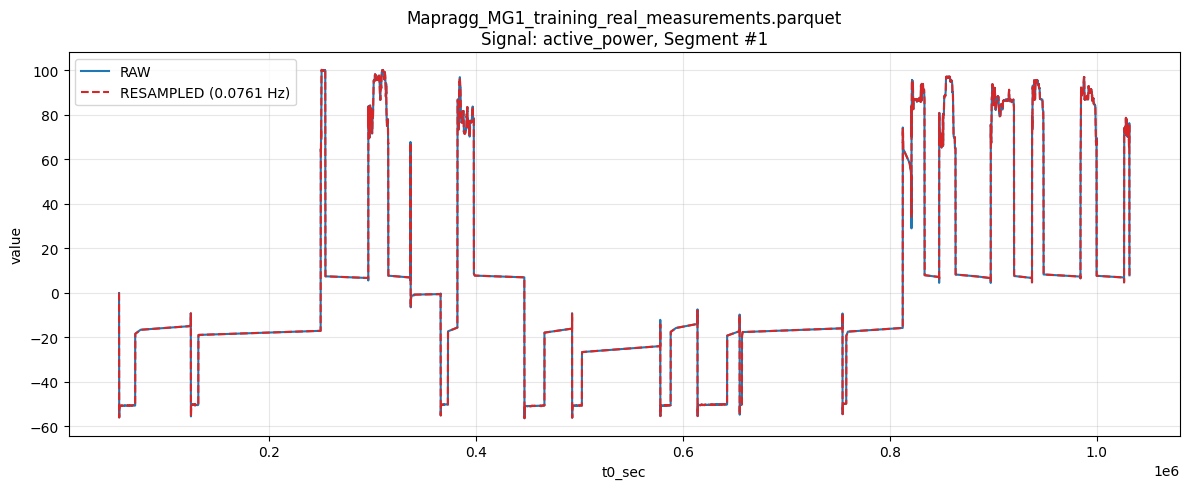

In [19]:
plot_raw_vs_resampled(
    "Mapragg_MG1_training_real_measurements.parquet",
    "active_power",
    1
)


In [20]:
# ============================================================
# FIXED-WINDOW SIGNAL VIEWER (SINGLE-PLOT FINAL VERSION)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import widgets, VBox, Output, interactive_output


def plot_resampled_segment_with_window(WINDOW_LENGTH=10.0):

    #------------------------------------------------------------
    # MAIN WIDGETS
    #------------------------------------------------------------
    file_dd = widgets.Dropdown(
        options=sorted(all_segments_resampled.keys()),
        description="Parquet",
        layout={"width": "400px"}
    )

    seg_slider = widgets.IntSlider(
        description="Segment",
        min=0, max=0, value=0, step=1,
        continuous_update=False,
        layout={"width": "400px"}
    )

    slider_box = VBox()
    plot_out = Output()

    # FLAG TO PREVENT DOUBLE PLOTTING
    initializing = {"active": True}

    #------------------------------------------------------------
    # VIEWER FUNCTION
    #------------------------------------------------------------
    def viewer(filename, seg_index, window_start):

        if initializing["active"]:
            return

        signals = [
            "active_power",
            "guide_vane_position",
            "water_pressure_downstream",
            "water_pressure_upstream",
            "ball_valve_closed",
            "ball_valve_open",
        ]

        units = {
            "active_power": "[W]",
            "guide_vane_position": "[%]",
            "water_pressure_downstream": "[bar]",
            "water_pressure_upstream": "[bar]",
            "ball_valve_closed": "[-]",
            "ball_valve_open": "[-]",
        }

        colors = [
            "tab:blue", "tab:orange", "tab:green",
            "tab:red", "tab:purple", "tab:brown"
        ]

        segdict = all_segments_resampled[filename]

        t0 = window_start
        t1 = window_start + WINDOW_LENGTH

        fig, axes = plt.subplots(
            len(signals), 1,
            figsize=(12, 2.6 * len(signals)),
            sharex=False           # <- IMPORTANT to let each subplot have ticks
        )

        for ax, sig, color in zip(axes, signals, colors):

            seg = segdict[sig][seg_index]
            mask = (seg["t0_sec"] >= t0) & (seg["t0_sec"] <= t1)
            seg_win = seg.loc[mask]

            ax.plot(seg_win["t0_sec"], seg_win["value"], color=color)
            ax.set_ylabel(f"{sig.replace('_',' ')} {units[sig]}", fontsize=9)
            ax.set_xlabel("time [s]", fontsize=9)
            ax.grid(True, alpha=0.3)

            # ---- NEW: explicit tick labels ----
            xticks = np.linspace(t0, t1, 5)
            ax.set_xticks(xticks)
            ax.set_xticklabels([f"{x:.0f}" for x in xticks], fontsize=8)

        fig.suptitle(
            f"{filename} – Segment {seg_index+1}",
            y=1.02
        )
        plt.tight_layout()
        plt.show()



    #------------------------------------------------------------
    # SEGMENT SLIDER UPDATE
    #------------------------------------------------------------
    def update_seg_slider(*args):
        fname = file_dd.value
        seg_slider.max = len(all_segments_resampled[fname]["active_power"]) - 1
        seg_slider.value = 0

    file_dd.observe(update_seg_slider, names="value")
    update_seg_slider()

    #------------------------------------------------------------
    # BUILD SLIDER
    #------------------------------------------------------------
    def build_slider(t_min, t_max):
        duration = t_max - t_min

        if duration <= WINDOW_LENGTH:
            return widgets.FloatSlider(
                description="Start time",
                min=t_min, max=t_min, value=t_min,
                continuous_update=False,
                layout={"width": "90%"}
            )

        return widgets.FloatSlider(
            description="Start time",
            min=t_min, max=t_max - WINDOW_LENGTH,
            value=t_min,
            step=WINDOW_LENGTH / 200,
            continuous_update=False,
            layout={"width": "90%"}
        )

    #------------------------------------------------------------
    # REBUILD SLIDER AND CONNECT VIEWER
    #------------------------------------------------------------
    def rebuild_slider(*args):
        fname = file_dd.value
        seg_idx = seg_slider.value
        seg = all_segments_resampled[fname]["active_power"][seg_idx]

        if len(seg) < 2:
            s = widgets.FloatSlider(description="Start time", min=0, max=0, value=0, disabled=True)
            slider_box.children = (s,)
            return

        t_min = float(seg["t0_sec"].min())
        t_max = float(seg["t0_sec"].max())

        if not np.isfinite(t_min) or not np.isfinite(t_max):
            s = widgets.FloatSlider(description="Start time", min=0, max=0, value=0, disabled=True)
            slider_box.children = (s,)
            return

        if t_max <= t_min:
            t_max = t_min + 1e-6

        # Build new slider
        new_slider = build_slider(t_min, t_max)

        # Connect viewer
        out = interactive_output(
            viewer,
            {
                "filename": file_dd,
                "seg_index": seg_slider,
                "window_start": new_slider
            }
        )

        plot_out.clear_output(wait=True)
        with plot_out:
            display(out)

        slider_box.children = (new_slider,)

    # Observers
    file_dd.observe(rebuild_slider, names="value")
    seg_slider.observe(rebuild_slider, names="value")

    # First run (no plot)
    rebuild_slider()
    initializing["active"] = False  # allow plotting now

    #------------------------------------------------------------
    display(VBox([file_dd, seg_slider, slider_box, plot_out]))


# RUN IT
plot_resampled_segment_with_window(WINDOW_LENGTH=10000.0)


Output()

# Active power segragation into Turbine/Pump/Other


In [21]:
def extract_active_power(df):
    """Extract active power as a time series with datetime index."""
    ap = df[df["signal_name"] == "active_power"][["ts", "value"]].copy()
    if ap.empty:
        raise ValueError("No active_power signal found.")
    
    ap = ap.sort_values("ts").set_index("ts")

    # Ensure monotonic index
    ap = ap[~ap.index.duplicated(keep="first")]
    
    return ap["value"]


def detect_steady_states(
    P,
    roll_sec=60,            # rolling window (sec)
    std_thr=1.0,            # max allowed rolling std for steady state
    min_power=5.0,          # minimum |Power| to be considered "active"
    min_duration=30         # min length of a stable segment (sec)
):
    """
    Detect stable segments in active power signal.
    Returns: list of dicts with start, end, mean_power, classification
    """

    # Determine approximate sampling interval
    dt = P.index.to_series().diff().median().total_seconds()
    if pd.isna(dt) or dt <= 0:
        dt = 1.0

    win = max(1, int(round(roll_sec / dt)))

    # Rolling standard deviation for stability check
    P_std = P.rolling(win, center=True, min_periods=1).std()

    # Condition for steady: low std AND |P| > min_power
    steady_mask = (P_std <= std_thr) & (P.abs() >= min_power)

    # Create segments from steady_mask changes
    segments = []
    seg_id = (steady_mask != steady_mask.shift()).cumsum()

    for _, seg_idx in P.groupby(seg_id):
        idx = seg_idx.index

        # Check steady or not
        is_steady = steady_mask.loc[idx].iloc[0]

        start = idx.min()
        end   = idx.max()
        duration = (end - start).total_seconds()

        if not is_steady:
            continue  # skip non-steady intervals

        if duration < min_duration:
            continue  # too short → ignore

        P_mean = P.loc[idx].mean()

        # classify
        if P_mean > min_power:
            mode = "turbine"
        elif P_mean < -min_power:
            mode = "pump"
        else:
            mode = "other"

        segments.append({
            "start": start,
            "end": end,
            "duration_sec": duration,
            "mean_power": P_mean,
            "mode": mode
        })

    return segments


def classify_modes_in_df(df, **kwargs):
    """
    Adds 'mode' column to full dataframe:
    - turbine
    - pump
    - other
    - transient (everything outside steady segments)
    """
    P = extract_active_power(df)
    segments = detect_steady_states(P, **kwargs)

    # default: everything transient
    df = df.sort_values("ts").copy()
    df["mode"] = "transient"

    # fill steady segments with labels
    for seg in segments:
        mask = (df["ts"] >= seg["start"]) & (df["ts"] <= seg["end"])
        df.loc[mask, "mode"] = seg["mode"]

    return df, segments


In [22]:
df = pd.read_parquet("Mapragg_MG1_training_real_measurements.parquet")
df["ts"] = pd.to_datetime(df["ts"])

df = df.merge(df_mapping, on="signal_id", how="left")

df_modes, steady_segments = classify_modes_in_df(
    df,
    roll_sec=60,
    std_thr=1.0,
    min_power=5.0,
    min_duration=30
)

print("Detected steady segments:")
for seg in steady_segments:
    print(seg)


Detected steady segments:
{'start': Timestamp('2020-06-03 08:52:15.904000+0000', tz='UTC'), 'end': Timestamp('2020-06-03 09:46:40.630000+0000', tz='UTC'), 'duration_sec': 3264.726, 'mean_power': np.float64(76.7876388107521), 'mode': 'turbine'}
{'start': Timestamp('2020-06-03 09:46:48.091000+0000', tz='UTC'), 'end': Timestamp('2020-06-03 10:00:16.813000+0000', tz='UTC'), 'duration_sec': 808.722, 'mean_power': np.float64(78.349120367141), 'mode': 'turbine'}
{'start': Timestamp('2020-06-03 10:00:31.019000+0000', tz='UTC'), 'end': Timestamp('2020-06-03 10:01:15.850000+0000', tz='UTC'), 'duration_sec': 44.831, 'mean_power': np.float64(71.37403945922851), 'mode': 'turbine'}
{'start': Timestamp('2020-06-03 16:54:35.840000+0000', tz='UTC'), 'end': Timestamp('2020-06-03 17:30:22.409000+0000', tz='UTC'), 'duration_sec': 2146.569, 'mean_power': np.float64(69.78574716009895), 'mode': 'turbine'}
{'start': Timestamp('2020-06-03 17:30:51.763000+0000', tz='UTC'), 'end': Timestamp('2020-06-03 18:00:21.

In [26]:
SIGNALS_FOR_CORR = [
    "active_power",
    "guide_vane_position",
    "water_pressure_downstream",
    "water_pressure_upstream",
    "ball_valve_closed", 
    "ball_valve_open",
]

def fix_sarelli_power_sign(df):
    """
    Invert active_power for Sarelli only.
    Applies AFTER merging with df_mapping.
    """

    mask = (df["stage"] == "Sarelli") & (df["signal_name"] == "active_power")
    df.loc[mask, "value"] *= -1
    return df


# ============================================================
# 1. UTILITY: Extract active power
# ============================================================
def extract_active_power(df):
    ap = df[df["signal_name"] == "active_power"][["ts", "value"]].copy()
    if ap.empty:
        raise ValueError("No active_power signal found in df.")

    ap = ap.sort_values("ts").set_index("ts")
    ap = ap[~ap.index.duplicated()]
    return ap["value"]


# ============================================================
# 2. Detect steady-state windows based on active power stability
# ============================================================
def detect_steady_states(
    P,
    roll_sec=60,         # rolling window for std
    std_thr=1.0,         # max std allowed for steady-state
    min_power=5.0,       # threshold for turbine/pump differentiation
    min_duration=30      # segment min duration (seconds)
):
    dt = P.index.to_series().diff().median().total_seconds()
    if pd.isna(dt) or dt <= 0:
        dt = 1.0

    win = max(1, int(round(roll_sec / dt)))

    P_std = P.rolling(win, center=True, min_periods=1).std()

    steady_mask = (P_std <= std_thr) & (P.abs() >= min_power)

    segments = []
    seg_id = (steady_mask != steady_mask.shift()).cumsum()

    for _, seg in P.groupby(seg_id):
        idx = seg.index
        is_steady = steady_mask.loc[idx].iloc[0]

        if not is_steady:
            continue

        start = idx.min()
        end = idx.max()
        duration = (end - start).total_seconds()
        if duration < min_duration:
            continue

        P_mean = P.loc[idx].mean()

        # classification
        if P_mean >= min_power:
            mode = "turbine"
        elif P_mean <= -min_power:
            mode = "pump"
        else:
            mode = "other"

        segments.append({
            "start": start,
            "end": end,
            "duration": duration,
            "mean_power": P_mean,
            "mode": mode
        })

    return segments


# ============================================================
# 3. Add "mode" column to entire dataframe
# ============================================================
def classify_modes_in_df(df, **kwargs):
    df = df.sort_values("ts").copy()
    df["mode"] = "transient"

    P = extract_active_power(df)
    steady_segments = detect_steady_states(P, **kwargs)

    for seg in steady_segments:
        mask = (df["ts"] >= seg["start"]) & (df["ts"] <= seg["end"])
        df.loc[mask, "mode"] = seg["mode"]

    return df, steady_segments


# ============================================================
# 4. Split df into mode-homogeneous segments
# ============================================================
def split_into_mode_segments(df_modes):
    df_modes = df_modes.sort_values("ts").copy()
    seg_id = (df_modes["mode"] != df_modes["mode"].shift()).cumsum()

    mode_segments = []

    for _, segdf in df_modes.groupby(seg_id):
        mode = segdf["mode"].iloc[0]
        if mode == "transient":
            continue

        mode_segments.append({
            "mode": mode,
            "df": segdf.copy(),
            "start": segdf["ts"].min(),
            "end": segdf["ts"].max()
        })

    return mode_segments


# ============================================================
# 5. Convert segment to wide format
# ============================================================
def make_wide(seg_df, signals=SIGNALS_FOR_CORR):
    """
    Convert long-format segment into wide format for selected signals.
    index = ts, columns = signal_name, values = value
    """
    seg_df = seg_df[seg_df["signal_name"].isin(signals)]
    if seg_df.empty:
        return None

    pivot = seg_df.pivot_table(
        index="ts",
        columns="signal_name",
        values="value",
        aggfunc="mean",
    ).sort_index()

    # forward/backward fill in time
    pivot = pivot.ffill().bfill()

    # drop columns with no variance -> corr would be NaN
    var = pivot.var()
    pivot = pivot.loc[:, var > 0]

    if pivot.shape[1] < 2:
        return None  # not enough varying signals to correlate

    return pivot


# ============================================================
# FIXED segment_correlation()  — only one correct definition
# ============================================================

def segment_correlation(seg_df, signals=SIGNALS_FOR_CORR):
    """
    Compute full correlation matrix for the given segment.
    Uses make_wide() to ensure consistent signal coverage.
    Guarantees full matrix and diagonal=1.
    """
    wide = make_wide(seg_df, signals=signals)
    if wide is None:
        return None

    # Compute correlation
    C = wide.corr()

    # Reindex to ensure all required signals appear
    C = C.reindex(index=signals, columns=signals)

    # Replace diagonal with 1.0
    np.fill_diagonal(C.values, 1.0)

    return C



# ============================================================
# 7. Aggregate correlations per mode
# ============================================================
def aggregate_corrs(corr_list, signals=SIGNALS_FOR_CORR):
    """
    Aggregate a list of correlation DataFrames using NaN-aware mean.
    Returns a DataFrame with index/columns = signals.
    """
    if not corr_list:
        return None

    mats = []
    for C in corr_list:
        if C is None:
            continue
        # reindex to full signal set; missing entries -> NaN
        C2 = C.reindex(index=signals, columns=signals)
        mats.append(C2.to_numpy(dtype=float))

    if not mats:
        return None

    arr = np.stack(mats, axis=0)           # shape: (n_segments, n_signals, n_signals)
    m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging

    return pd.DataFrame(m, index=signals, columns=signals)



# ============================================================
# 8. FULL PARQUET PIPELINE
# ============================================================
def process_parquet(path, df_mapping,
                    roll_sec=60, std_thr=1.0,
                    min_power=5.0, min_duration=30):

    print(f"\n=== Processing {path} ===")

    df = pd.read_parquet(path)
    df["ts"] = pd.to_datetime(df["ts"], utc=False)

    # ----------------------------------------
    # Merge FIRST so stage and signal_name exist
    # ----------------------------------------
    df = df.merge(df_mapping, on="signal_id", how="left")

    # ----------------------------------------
    # FIX SARELLI SIGN BEFORE ANY PROCESSING
    # ----------------------------------------
    df = fix_sarelli_power_sign(df)

    # ----------------------------------------
    # Mode classification & segment extraction
    # ----------------------------------------
    df_modes, steady_segments = classify_modes_in_df(
        df,
        roll_sec=roll_sec,
        std_thr=std_thr,
        min_power=min_power,
        min_duration=min_duration
    )

    print(f"Detected {len(steady_segments)} steady segments.")

    # Segment per mode (steady only)
    mode_segments = split_into_mode_segments(df_modes)

    # ----------------------------------------
    # Correlation tables for steady modes
    # ----------------------------------------
    turbine_corrs = []
    pump_corrs = []
    other_corrs = []

    for seg in mode_segments:
        C = segment_correlation(seg["df"], signals=SIGNALS_FOR_CORR)
        if C is None:
            continue

        if seg["mode"] == "turbine":
            turbine_corrs.append(C)
        elif seg["mode"] == "pump":
            pump_corrs.append(C)
        else:
            other_corrs.append(C)

    agg_turbine = aggregate_corrs(turbine_corrs, signals=SIGNALS_FOR_CORR)
    agg_pump    = aggregate_corrs(pump_corrs,    signals=SIGNALS_FOR_CORR)
    agg_other   = aggregate_corrs(other_corrs,   signals=SIGNALS_FOR_CORR)

    # ----------------------------------------
    # NEW: Correlation for all remaining data (not turbine, not pump)
    #      This includes transient + any 'other' or additional modes.
    # ----------------------------------------
    mask_rest = ~df_modes["mode"].isin(["turbine", "pump"])
    if mask_rest.any():
        rest_df = df_modes[mask_rest]
        corr_rest = segment_correlation(rest_df, signals=SIGNALS_FOR_CORR)
    else:
        corr_rest = None

    return {
        "file": path,
        "df_modes": df_modes,
        "segments": mode_segments,
        "corr_turbine": agg_turbine,
        "corr_pump": agg_pump,
        "corr_other": agg_other,
        "corr_rest": corr_rest,   # <- NEW
    }


In [27]:
def plot_mode_corr_heatmaps(result_dict):
    file = result_dict["file"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # TURBINE
    if result_dict["corr_turbine"] is not None:
        sns.heatmap(result_dict["corr_turbine"], vmin=-1, vmax=1,
                    cmap="coolwarm", ax=axes[0])
        axes[0].set_title(f"{file}\nTURBINE correlation")
    else:
        axes[0].set_title("No turbine steady-state segments")

    # PUMP
    if result_dict["corr_pump"] is not None:
        sns.heatmap(result_dict["corr_pump"], vmin=-1, vmax=1,
                    cmap="coolwarm", ax=axes[1])
        axes[1].set_title(f"{file}\nPUMP correlation")
    else:
        axes[1].set_title("No pump steady-state segments")

    # REMAINING (NOT TURBINE / NOT PUMP)
    if result_dict.get("corr_rest") is not None:
        sns.heatmap(result_dict["corr_rest"], vmin=-1, vmax=1,
                    cmap="coolwarm", ax=axes[2])
        axes[2].set_title(f"{file}\n TRANSIENT STATE correlation")
    else:
        axes[2].set_title("No remaining data for correlation")

    plt.tight_layout()
    plt.show()



=== Processing Mapragg_MG1_testing_real_measurements.parquet ===
Detected 701 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


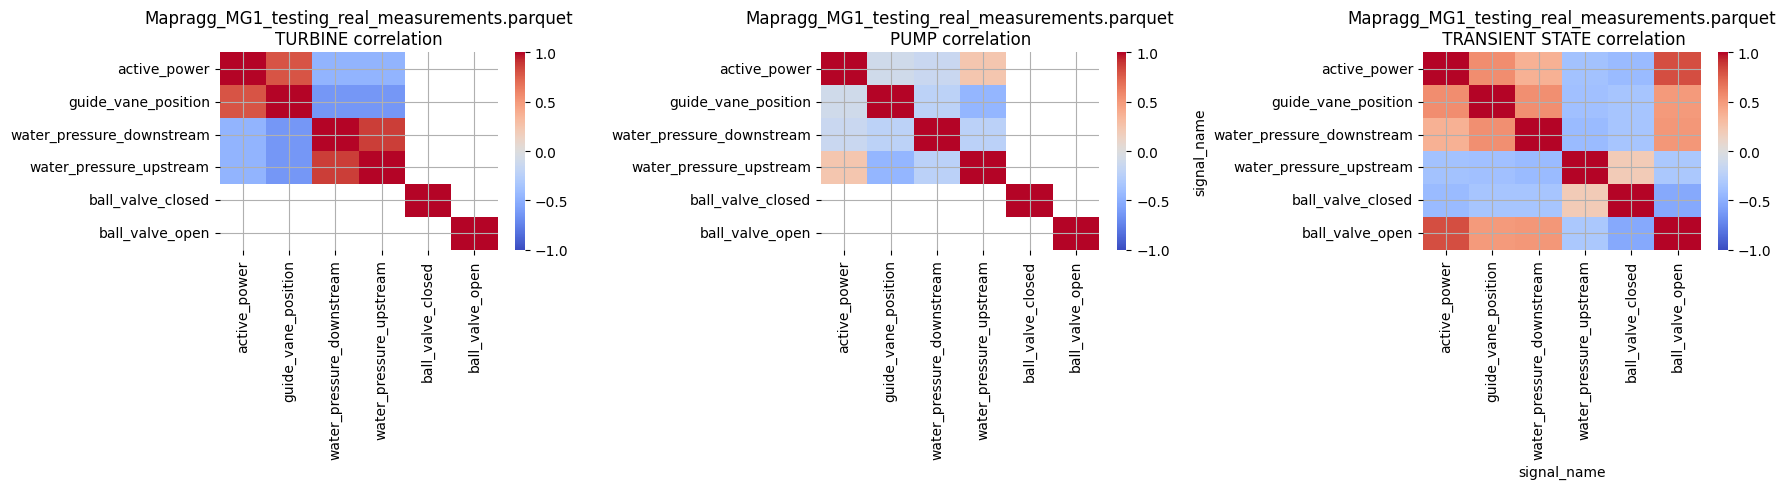


=== Processing Mapragg_MG1_training_real_measurements.parquet ===
Detected 2552 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


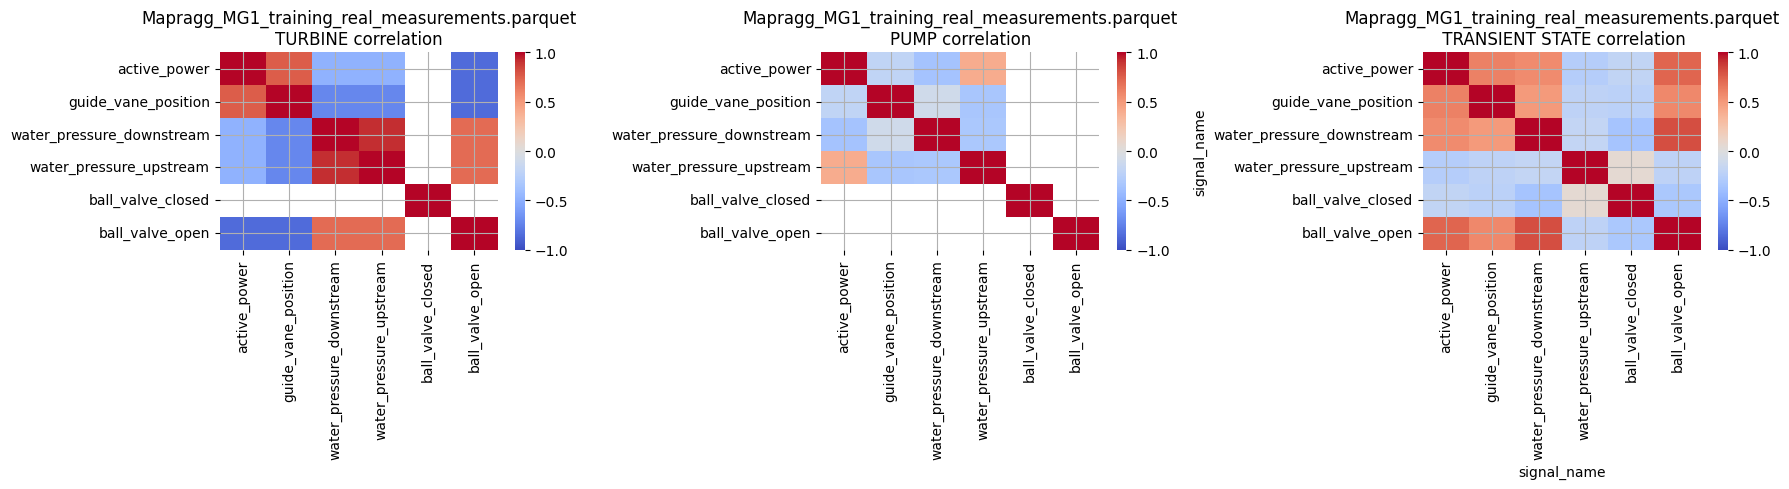


=== Processing Mapragg_MG2_testing_real_measurements.parquet ===
Detected 471 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


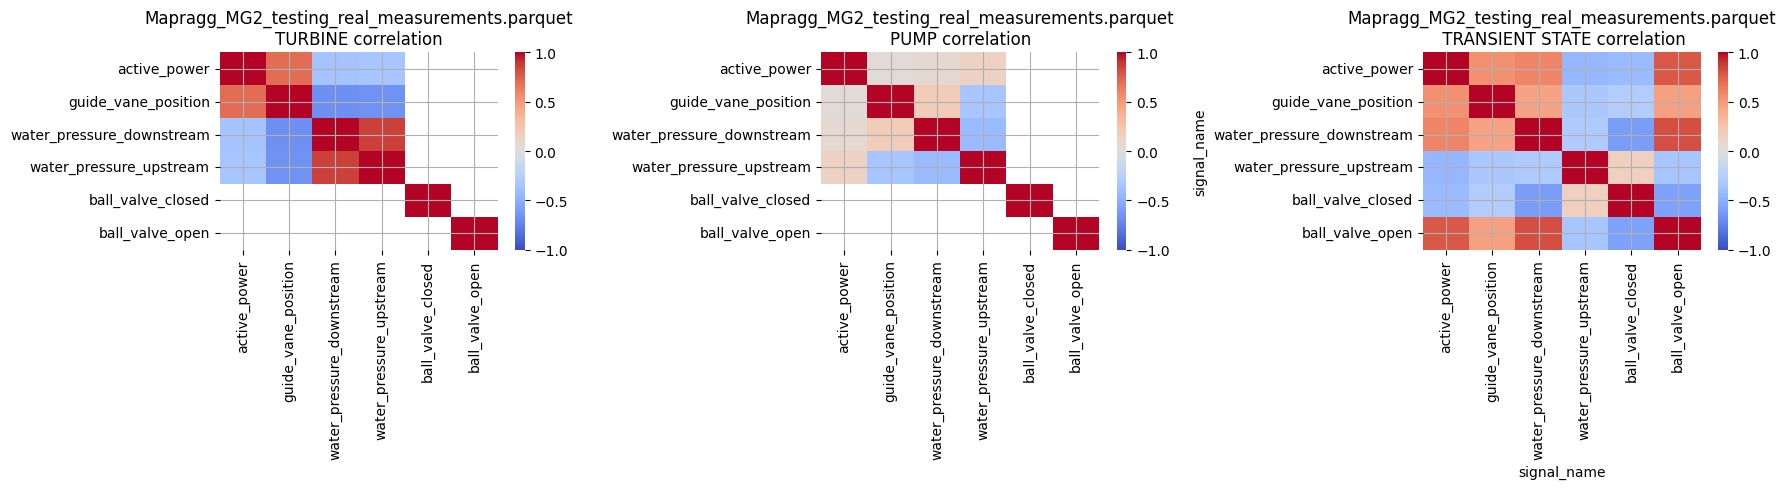


=== Processing Mapragg_MG2_training_real_measurements.parquet ===
Detected 5484 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


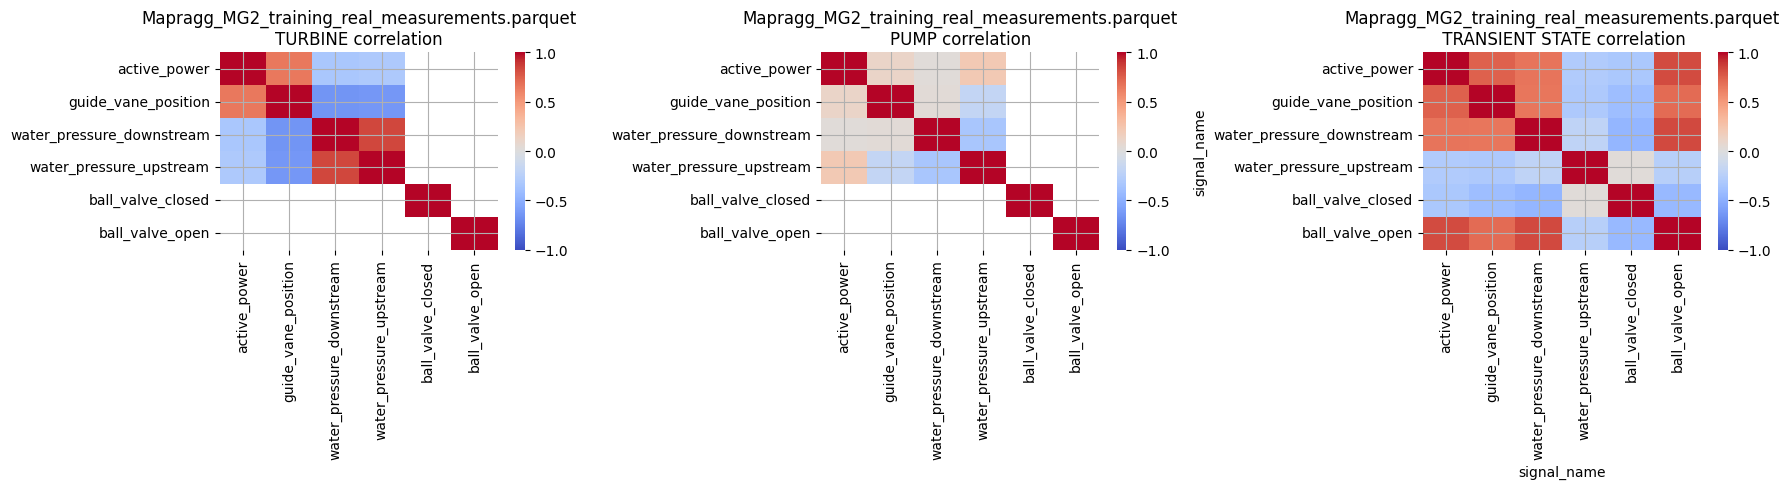


=== Processing Mapragg_MG3_testing_real_measurements.parquet ===
Detected 673 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


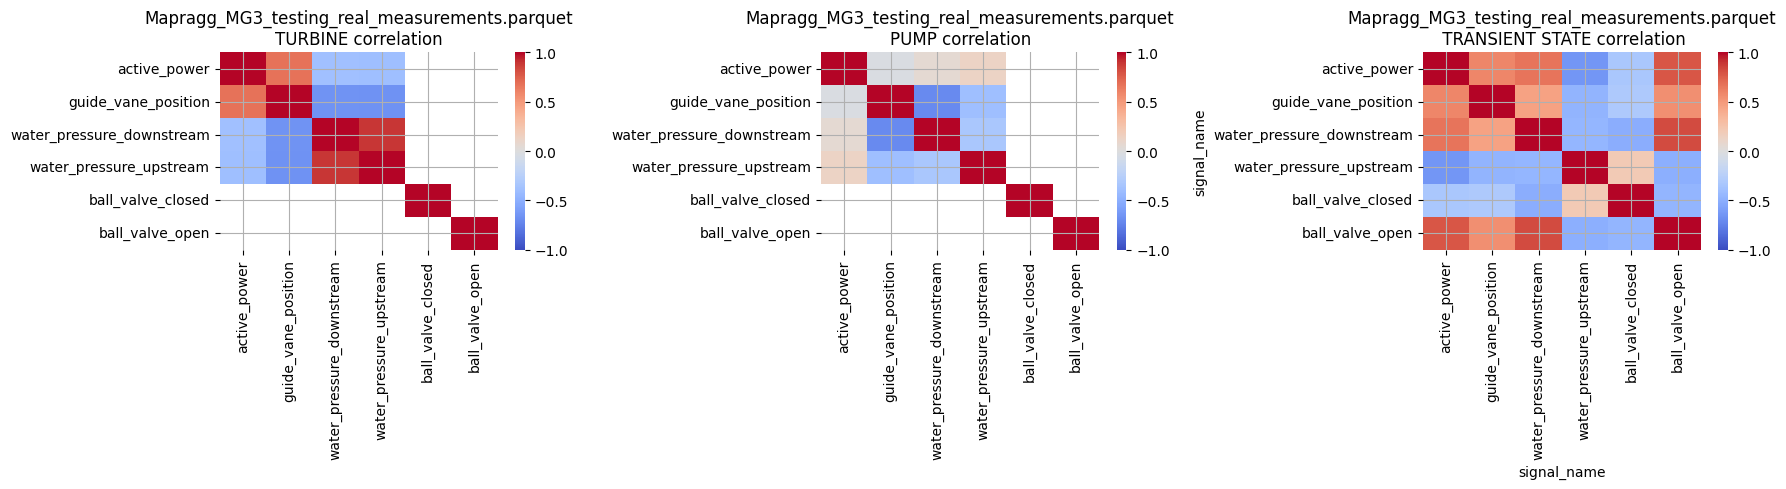


=== Processing Mapragg_MG3_training_real_measurements.parquet ===
Detected 2763 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


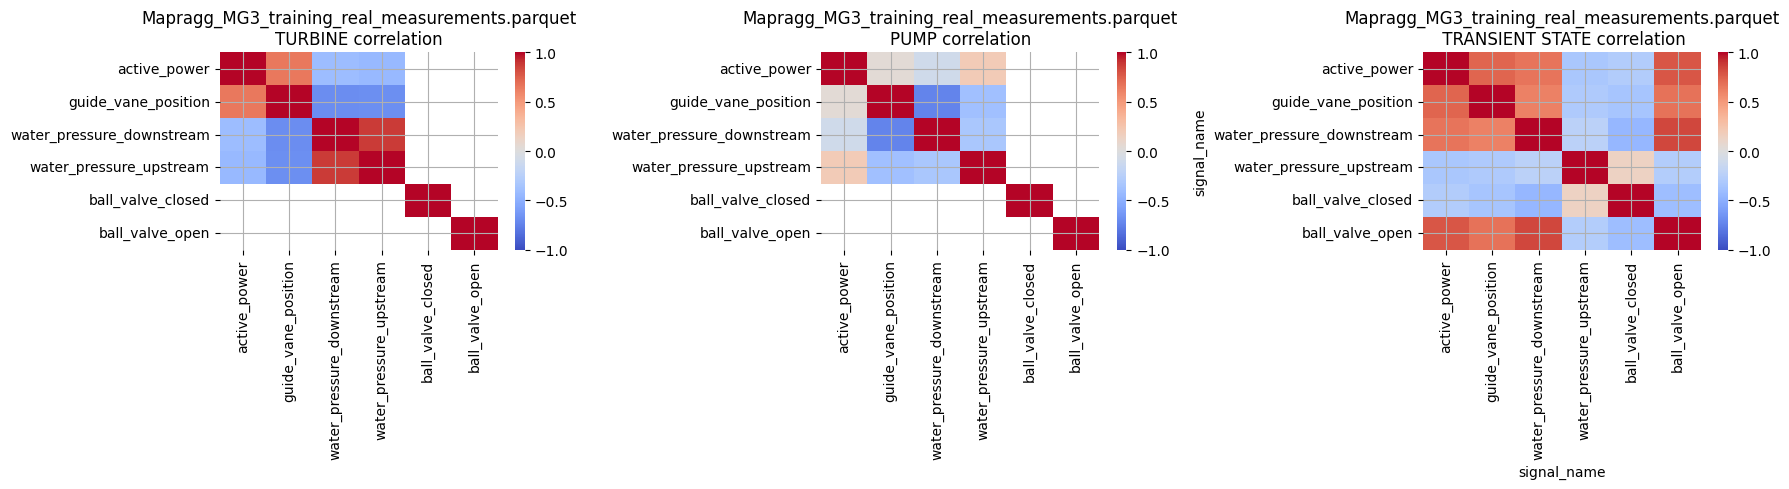


=== Processing Sarelli_MG1_testing_real_measurements.parquet ===
Detected 132 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


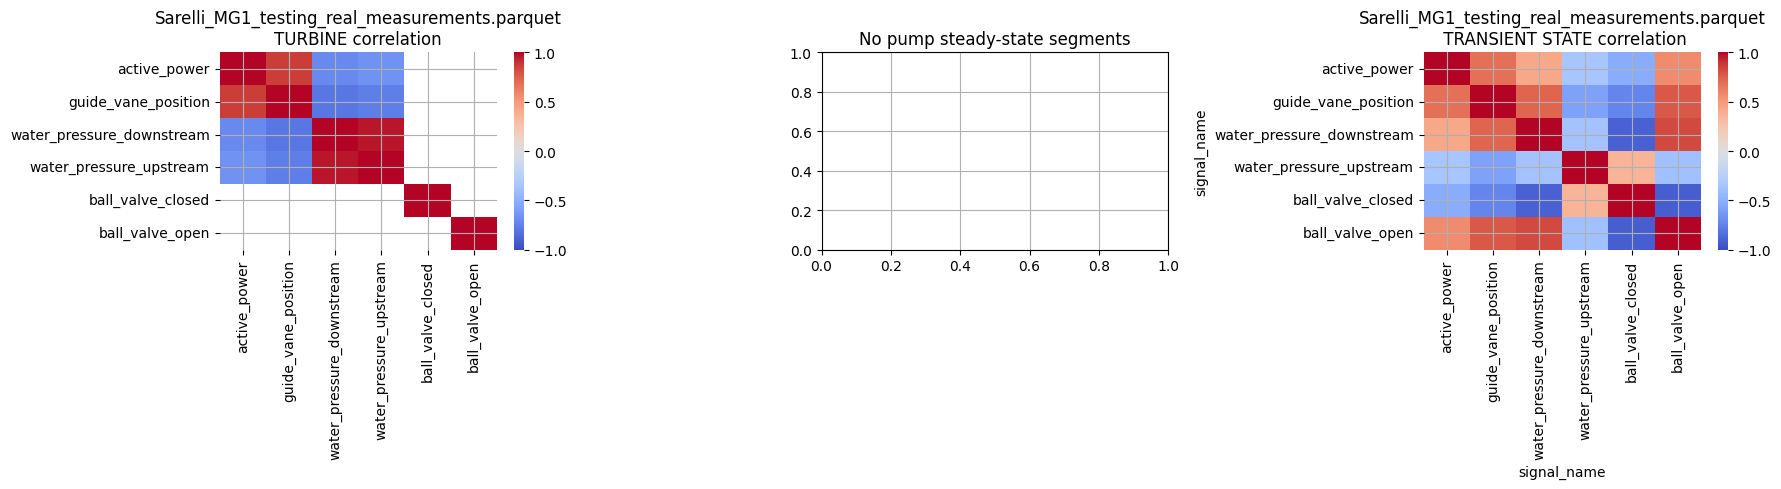


=== Processing Sarelli_MG1_training_real_measurements.parquet ===
Detected 422 steady segments.


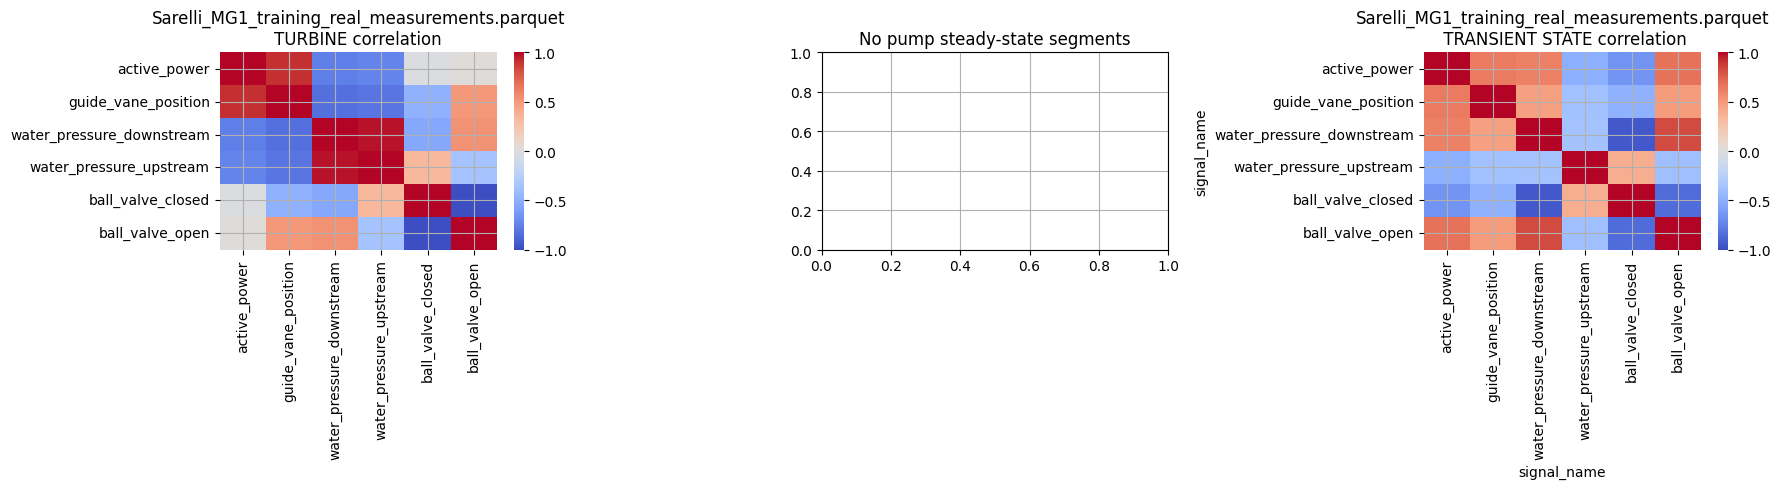


=== Processing Sarelli_MG2_testing_real_measurements.parquet ===
Detected 203 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


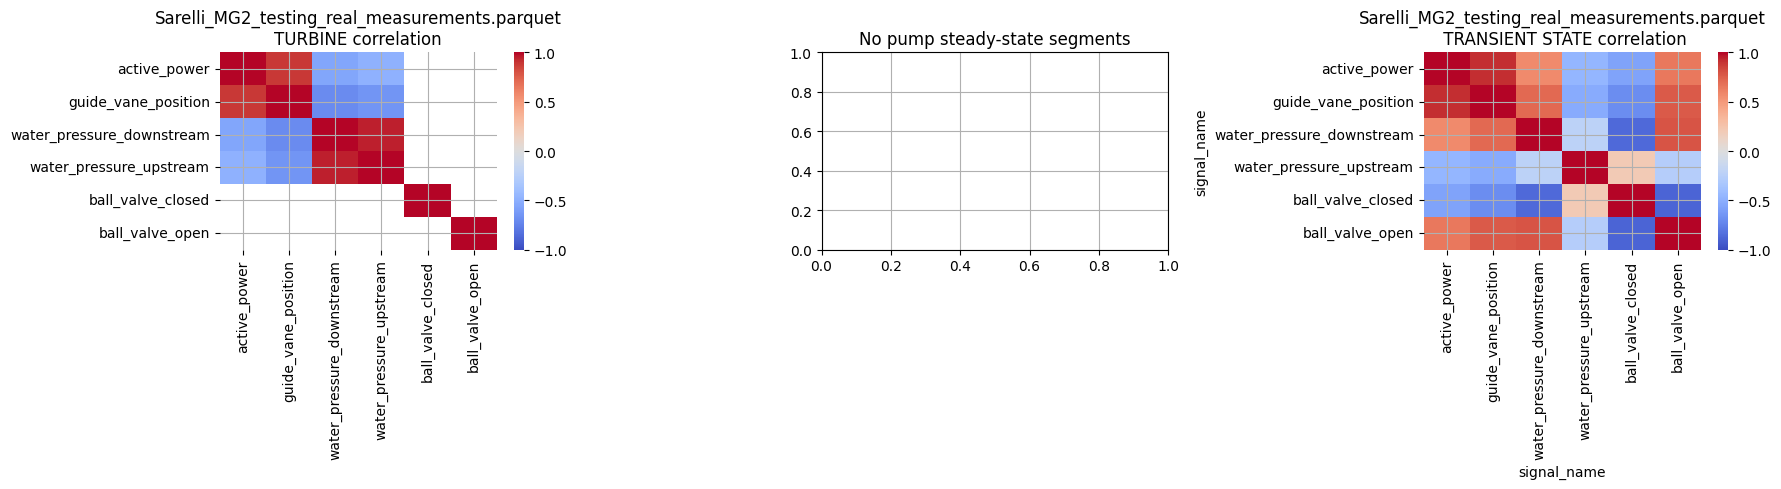


=== Processing Sarelli_MG2_training_real_measurements.parquet ===
Detected 934 steady segments.


/var/folders/t4/57x32m1x0z57n3k9h907l2580000gn/T/ipykernel_39565/2014374253.py:214: RuntimeWarning: Mean of empty slice
  m = np.nanmean(arr, axis=0)            # ignore NaNs when averaging


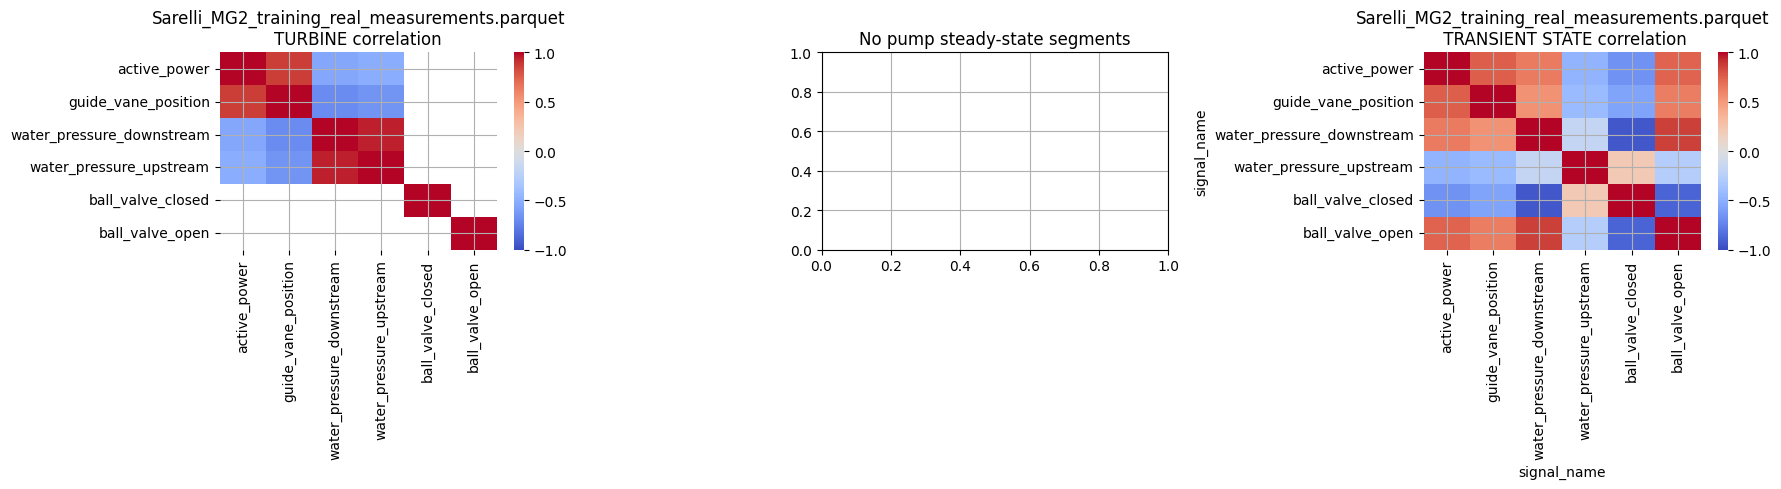

In [28]:
results = {}

for path in parquet_files:
    res = process_parquet(path, df_mapping)
    results[path] = res
    plot_mode_corr_heatmaps(res)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# The signals you want to analyze:
SIGNALS_FOR_DIST = [
    "active_power",
    "guide_vane_position",
    "water_pressure_downstream",
    "water_pressure_upstream",
    "ball_valve_closed",
    "ball_valve_open",
]

def extract_resampled_distributions(all_segments_resampled):
    """
    Returns a nested structure:
    distributions[station][dataset_type][signal] = describe()
    """

    distributions = {"Mapragg": {}, "Sarelli": {}}

    for parquet_name, entry in all_segments_resampled.items():
        
        station = entry["stage"]        # "Mapragg" or "Sarelli"
        dtype   = entry["dataset_type"] # "training" or "testing"

        if dtype not in distributions[station]:
            distributions[station][dtype] = {}

        # Loop over signals
        for sig in SIGNALS_FOR_DIST:
            seglist = entry[sig] if sig in entry else None
            if seglist is None:
                continue

            # Combine all resampled segments for this parquet + signal
            df_combined = pd.concat(seglist, ignore_index=True)

            if sig not in distributions[station][dtype]:
                distributions[station][dtype][sig] = [df_combined["value"]]
            else:
                distributions[station][dtype][sig].append(df_combined["value"])

    # Convert lists of arrays → descriptive statistics
    for station in distributions:
        for dtype in distributions[station]:
            for sig in distributions[station][dtype]:
                values = pd.concat(distributions[station][dtype][sig], ignore_index=True)
                distributions[station][dtype][sig] = values.describe(percentiles=[0.05, 0.5, 0.95])

    return distributions


# ---- RUN IT ----
resampled_dists = extract_resampled_distributions(all_segments_resampled)

print("=== Mapragg — Training ===")
print(resampled_dists["Mapragg"]["training"])

print("\n=== Mapragg — Testing ===")
print(resampled_dists["Mapragg"]["testing"])

print("\n=== Sarelli — Training ===")
print(resampled_dists["Sarelli"]["training"])

print("\n=== Sarelli — Testing ===")
print(resampled_dists["Sarelli"]["testing"])


=== Mapragg — Training ===
{'active_power': count    6.037082e+06
mean     1.101003e+00
std      4.178224e+01
min     -6.070358e+01
5%      -5.155593e+01
50%     -7.296253e-01
95%      9.217306e+01
max      1.173420e+02
Name: value, dtype: float64, 'guide_vane_position': count    6.372748e+06
mean     2.717989e+01
std      3.963860e+01
min      0.000000e+00
5%       7.276895e-02
50%      6.666378e-01
95%      9.984548e+01
max      9.999726e+01
Name: value, dtype: float64, 'water_pressure_downstream': count    6.374345e+06
mean     6.602784e+00
std      1.596515e+01
min     -1.337714e+00
5%      -1.162263e+00
50%      1.433193e-01
95%      4.549170e+01
max      5.006855e+01
Name: value, dtype: float64, 'water_pressure_upstream': count    6.375086e+06
mean     4.669184e+01
std      1.966175e+00
min      3.643536e-01
5%       4.303295e+01
50%      4.731643e+01
95%      4.880642e+01
max      5.038498e+01
Name: value, dtype: float64, 'ball_valve_closed': count    6.047872e+06
mean     8.370

In [ ]:
def plot_resampled_histograms(all_segments_resampled, bins=80):

    # Mapping from signal_name → nice title + x-axis label
    LABELS = {
        "active_power": ("Active power", "Active power [MW]"),
        "guide_vane_position": ("Guide vane position", "Guide vane position [%]"),
        "water_pressure_downstream": ("Downward water pressure", "Downward water pressure [bar]"),
        "water_pressure_upstream": ("Upward water pressure", "Upward water pressure [bar]"),
        "ball_valve_closed": ("Ball valve closed", "Ball valve closed [-]"),
        "ball_valve_open": ("Ball valve open", "Ball valve open [-]"),
    }

    colors = {"training": "steelblue", "testing": "firebrick"}

    for station in ["Mapragg", "Sarelli"]:

        # Collect data grouped by dataset type
        grouped = {"training": {}, "testing": {}}

        for parquet_name, entry in all_segments_resampled.items():
            if entry["stage"] != station:
                continue

            dtype = entry["dataset_type"]

            # gather per-signal resampled values
            for sig in SIGNALS_FOR_DIST:
                seglist = entry.get(sig, [])
                if not seglist:
                    continue
                df_sig = pd.concat(seglist, ignore_index=True)

                if sig not in grouped[dtype]:
                    grouped[dtype][sig] = [df_sig["value"]]
                else:
                    grouped[dtype][sig].append(df_sig["value"])

        # --- Create 3×2 grid ---
        fig, axes = plt.subplots(3, 2, figsize=(14, 12))
        fig.suptitle(f"{station} — Resampled Signal Distributions", fontsize=18)

        axes = axes.flatten()

        for ax, sig in zip(axes, SIGNALS_FOR_DIST):

            # Plot training/testing histograms
            for dtype in ["training", "testing"]:
                if sig not in grouped[dtype]:
                    continue

                vals = pd.concat(grouped[dtype][sig], ignore_index=True)

                ax.hist(vals, bins=bins, alpha=0.6,
                        color=colors[dtype], label=dtype)

            title, xlabel = LABELS[sig]
            ax.set_title(title)
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Count")
            ax.legend()

        # Clear any empty unused subplots (if any)
        for ax in axes[len(SIGNALS_FOR_DIST):]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()


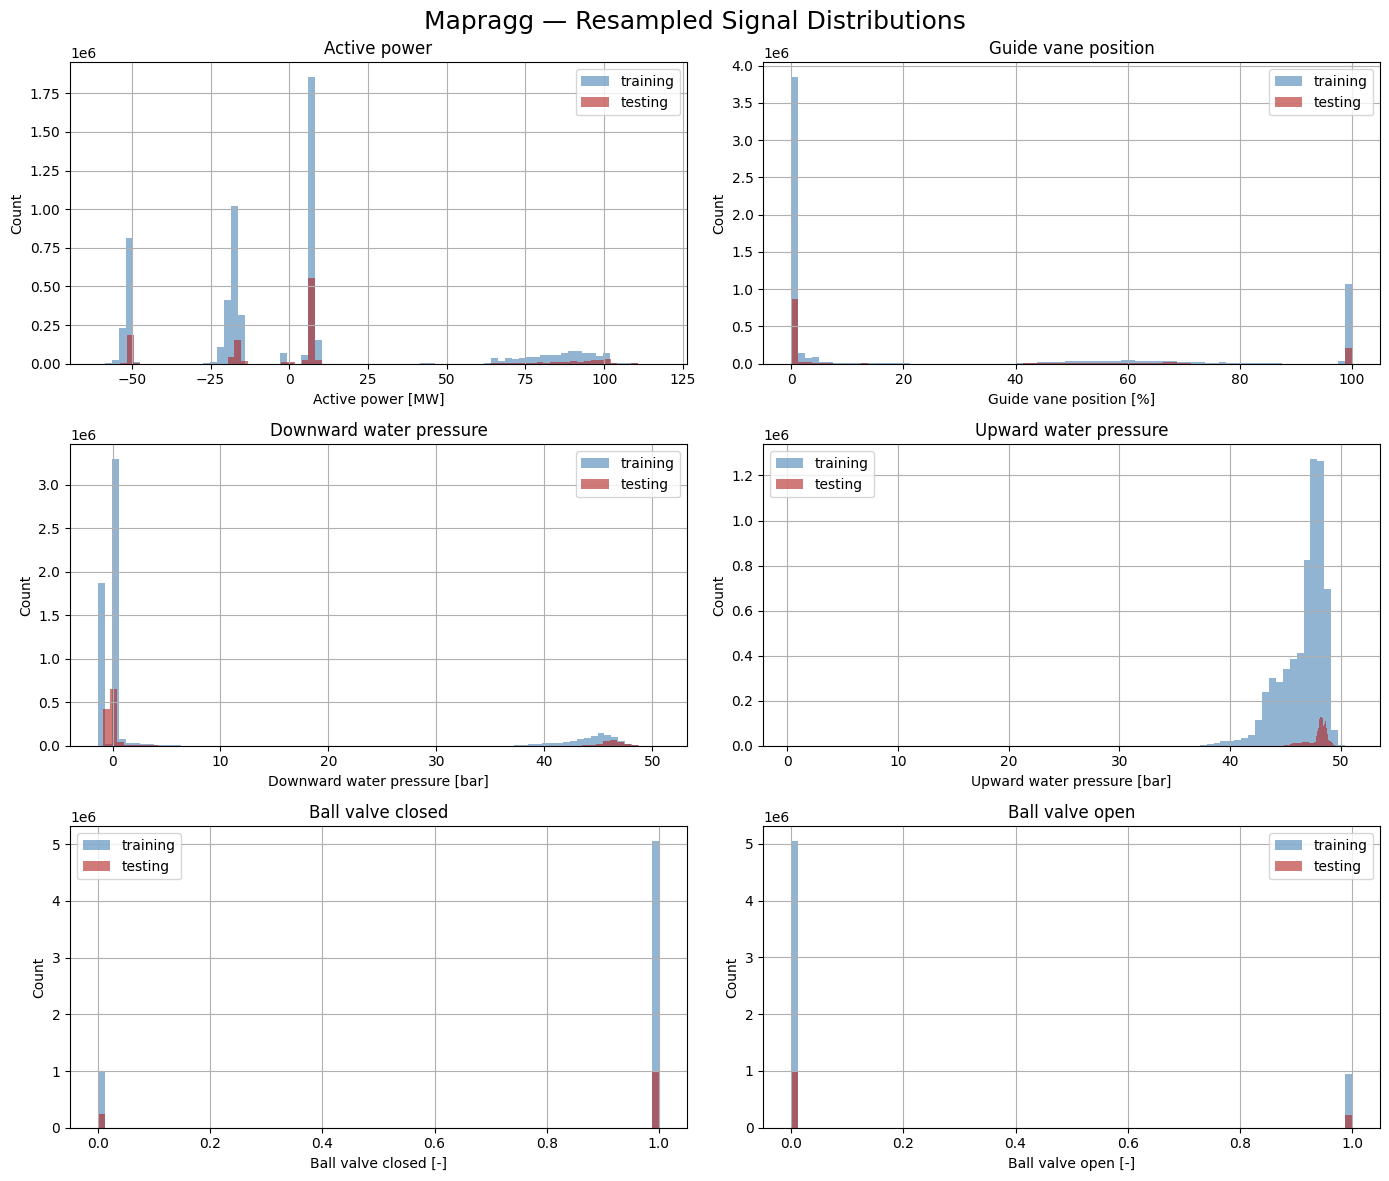

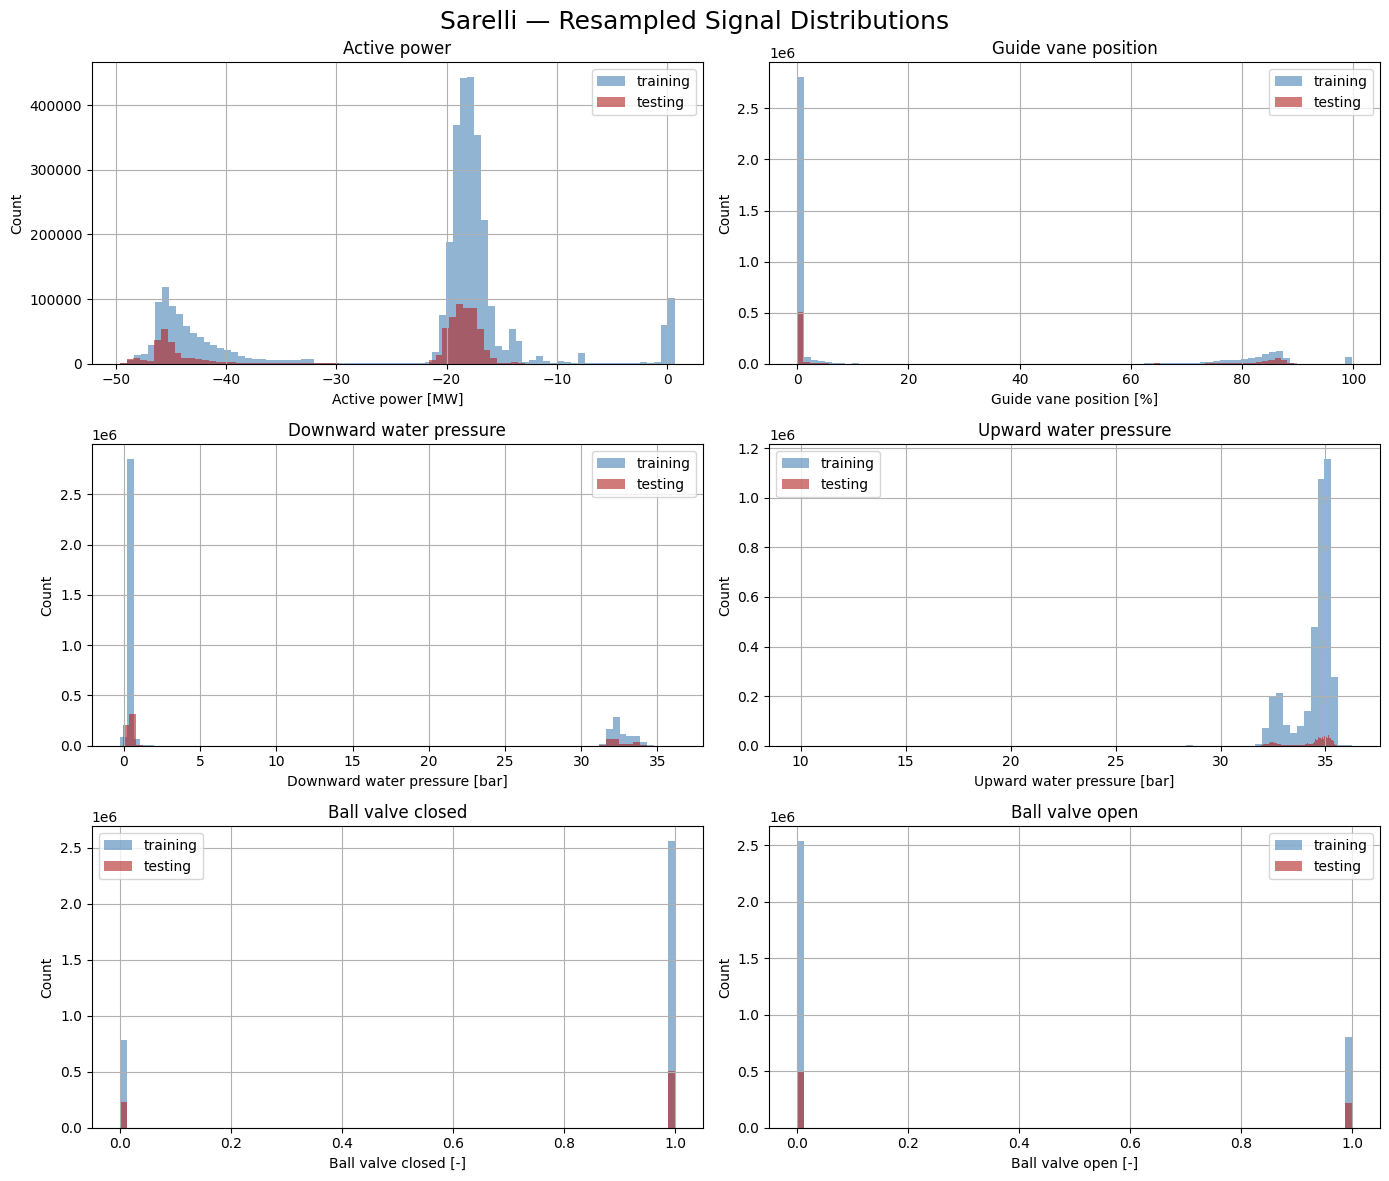

In [ ]:
plot_resampled_histograms(all_segments_resampled)


# Task 1


In [57]:
# ================================================================
# VALVE MOVEMENT DETECTION ARTIFACT
# ================================================================
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1) SAFE MERGING OF RESAMPLED SIGNALS
# ------------------------------------------------------------
def segment_to_joint_df(segdict, seg_idx):
    """
    Safely align the 4 analog signals for one segment:
    P, GV, P_down, P_up
    by outer-merging on t0_sec.
    Handles differing lengths across signals.
    """

    def extract(sig):
        return segdict[sig][seg_idx][["t0_sec", "value"]].rename(columns={"value": sig})

    dfP    = extract("active_power")
    dfGV   = extract("guide_vane_position")
    dfDown = extract("water_pressure_downstream")
    dfUp   = extract("water_pressure_upstream")

    df = (
        dfP.merge(dfGV, on="t0_sec", how="outer")
           .merge(dfDown, on="t0_sec", how="outer")
           .merge(dfUp, on="t0_sec", how="outer")
           .sort_values("t0_sec")
           .reset_index(drop=True)
    )

    # Fill small merge gaps
    df = df.ffill().bfill()

    # Rename for convenience
    df = df.rename(columns={
        "active_power": "P",
        "guide_vane_position": "GV",
        "water_pressure_downstream": "P_down",
        "water_pressure_upstream": "P_up"
    })
    return df


# ------------------------------------------------------------
# 2) MOVEMENT DETECTOR USING ROLLING STD
# ------------------------------------------------------------
def detect_valve_motion(df, window_sec=1.0, k=1000):
    """
    Detect valve motion (open or close) using analog signals only.
    Returns:
      movement: boolean Series (True = valve movement)
      score: float Series, combined variability
      threshold: float
    """

    # Compute sampling interval
    t = df["t0_sec"].values
    dt = np.median(np.diff(t))
    win = max(int(window_sec / dt), 5)

    # Rolling std per signal
    S1 = df["P"].rolling(win, center=True).std()      # active power
    S2 = df["GV"].rolling(win, center=True).std()     # guide vane
    S3 = df["P_up"].rolling(win, center=True).std()   # upstream pressure
    S4 = df["P_down"].rolling(win, center=True).std() # downstream pressure

    # Weighted combined score
    score = (
        0.1 * S1 +
        0.2 * S2 +
        0.4 * S3 +
        0.3 * S4
    )

    # Robust threshold using MAD
    med = score.median()
    mad = (score - med).abs().median()
    threshold = med + k * mad

    movement = score > threshold

    return movement, score, threshold


# ------------------------------------------------------------
# 3) EXTRACT MOVEMENT EVENTS (START AND END TIMES)
# ------------------------------------------------------------
def extract_motion_events(movement, t):
    """
    movement: boolean array or Series
    t: dataframe["t0_sec"] array
    Returns a list of (t_start, t_end).
    """
    movement = movement.values if hasattr(movement, "values") else movement
    t = np.asarray(t)

    events = []
    inside = False
    start = None

    for i in range(len(movement)):
        if movement[i] and not inside:
            inside = True
            start = t[i]
        if not movement[i] and inside:
            inside = False
            events.append((start, t[i]))

    if inside:
        events.append((start, t[-1]))

    return events

# ------------------------------------------------------------
# 3b) MERGE CLOSE EVENTS + ADD BUFFER
# ------------------------------------------------------------
def merge_and_expand_events(events, merge_gap=5.0, buffer=2.0):
    """
    events: list of (start, end) tuples
    merge_gap: max distance (seconds) between events to merge them
    buffer: seconds to extend before start and after end
    """
    if not events:
        return []

    # Sort by start time
    events = sorted(events)

    merged = []
    cur_start, cur_end = events[0]

    for (s, e) in events[1:]:
        # If next event starts close enough → merge
        if s <= cur_end + merge_gap:
            cur_end = max(cur_end, e)  # extend current merged event
        else:
            merged.append((cur_start, cur_end))
            cur_start, cur_end = s, e

    merged.append((cur_start, cur_end))

    # Add buffer zone
    expanded = [(s - buffer, e + buffer) for (s, e) in merged]

    return expanded



def detect_valve_events_in_parquet(parquet_name, all_segments_resampled,
                                   merge_gap=10000.0, buffer=20000.0):

    results = {}
    segdict = all_segments_resampled[parquet_name]

    n_seg = len(segdict["active_power"])
    print(f"Running valve-motion detection on {parquet_name} ({n_seg} segments)\n")

    for seg_idx in range(n_seg):
        df = segment_to_joint_df(segdict, seg_idx)
        movement, score, thr = detect_valve_motion(df)

        raw_events = extract_motion_events(movement, df["t0_sec"])
        cleaned_events = merge_and_expand_events(raw_events,
                                                 merge_gap=merge_gap,
                                                 buffer=buffer)

        results[seg_idx] = {
            "raw_events": raw_events,
            "cleaned_events": cleaned_events,
            "threshold": float(thr),
        }

        print(
            f"Segment {seg_idx+1}: "
            f"{len(raw_events)} raw → {len(cleaned_events)} cleaned events"
        )

    return results



In [58]:
TARGET = "Mapragg_MG1_training_real_measurements.parquet"

results = detect_valve_events_in_parquet(TARGET, all_segments_resampled)


Running valve-motion detection on Mapragg_MG1_training_real_measurements.parquet (16 segments)

Segment 1: 30 raw → 8 cleaned events
Segment 2: 146 raw → 28 cleaned events
Segment 3: 251 raw → 45 cleaned events
Segment 4: 266 raw → 55 cleaned events
Segment 5: 63 raw → 13 cleaned events
Segment 6: 323 raw → 60 cleaned events
Segment 7: 404 raw → 67 cleaned events
Segment 8: 523 raw → 91 cleaned events
Segment 9: 324 raw → 59 cleaned events
Segment 10: 290 raw → 54 cleaned events
Segment 11: 385 raw → 51 cleaned events
Segment 12: 225 raw → 32 cleaned events
Segment 13: 469 raw → 65 cleaned events
Segment 14: 475 raw → 55 cleaned events
Segment 15: 570 raw → 81 cleaned events
Segment 16: 61 raw → 15 cleaned events


In [59]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import widgets, VBox, Output, interactive_output

def plot_resampled_segment_with_window_and_valve(WINDOW_LENGTH=10.0):

    file_dd = widgets.Dropdown(
        options=sorted(all_segments_resampled.keys()),
        description="Parquet",
        layout={"width": "400px"}
    )

    seg_slider = widgets.IntSlider(
        description="Segment",
        min=0, max=0, value=0, step=1,
        continuous_update=False,
        layout={"width": "400px"}
    )

    slider_box = VBox()
    plot_out = Output()
    initializing = {"active": True}

    signals = [
        "active_power",
        "guide_vane_position",
        "water_pressure_downstream",
        "water_pressure_upstream",
        "ball_valve_closed",
        "ball_valve_open",
    ]

    units = {
        "active_power": "[W]",
        "guide_vane_position": "[%]",
        "water_pressure_downstream": "[bar]",
        "water_pressure_upstream": "[bar]",
        "ball_valve_closed": "[-]",
        "ball_valve_open": "[-]",
    }

    colors = [
        "tab:blue", "tab:orange", "tab:green",
        "tab:red", "tab:purple", "tab:brown"
    ]

    # --------------------------------------------------------
    # VIEWER FUNCTION
    # --------------------------------------------------------
    def viewer(filename, seg_index, window_start):

        if initializing["active"]:
            return

        segdict = all_segments_resampled[filename]

        # TIME WINDOW
        t0 = window_start
        t1 = window_start + WINDOW_LENGTH

        # Prepare movement detection (needs merged analog df)
        df_joint = segment_to_joint_df(segdict, seg_index)
        movement, score, thr = detect_valve_motion(df_joint)
        events = extract_motion_events(movement, df_joint["t0_sec"])

        # Filter events to window
        window_events = [(ts, te) for (ts, te) in events if te >= t0 and ts <= t1]

        # Create figure
        fig, axes = plt.subplots(
            len(signals), 1,
            figsize=(12, 2.6 * len(signals)),
            sharex=False
        )

        # --------------------------------------------------------
        # PLOTTING EACH SIGNAL
        # --------------------------------------------------------
        for ax, sig, color in zip(axes, signals, colors):

            seg = segdict[sig][seg_index]
            mask = (seg["t0_sec"] >= t0) & (seg["t0_sec"] <= t1)
            seg_win = seg.loc[mask]

            ax.plot(seg_win["t0_sec"], seg_win["value"], color=color)
            ax.set_ylabel(f"{sig.replace('_',' ')} {units[sig]}", fontsize=9)
            ax.grid(True, alpha=0.3)

            # Add event markers
            for (ts, te) in window_events:
                ax.axvline(ts, color="green", linestyle="--", linewidth=1, alpha=0.9)
                ax.axvline(te, color="green", linestyle="--", linewidth=1, alpha=0.9)
                ax.axvspan(ts, te, color="green", alpha=0.12)

            # x-ticks
            xticks = np.linspace(t0, t1, 5)
            ax.set_xticks(xticks)
            ax.set_xticklabels([f"{x:.0f}" for x in xticks], fontsize=8)

        fig.suptitle(f"{filename} – Segment {seg_index+1}", y=1.02)
        plt.tight_layout()
        plt.show()



    # --------------------------------------------------------
    # SEGMENT SLIDER UPDATE
    # --------------------------------------------------------
    def update_seg_slider(*args):
        fname = file_dd.value
        seg_slider.max = len(all_segments_resampled[fname]["active_power"]) - 1
        seg_slider.value = 0

    file_dd.observe(update_seg_slider, names="value")
    update_seg_slider()

    # --------------------------------------------------------
    # BUILD TIME SLIDER
    # --------------------------------------------------------
    def build_slider(t_min, t_max):
        duration = t_max - t_min
        if duration <= WINDOW_LENGTH:
            return widgets.FloatSlider(
                description="Start time",
                min=t_min, max=t_min, value=t_min,
                continuous_update=False,
                layout={"width": "90%"}
            )
        return widgets.FloatSlider(
            description="Start time",
            min=t_min, max=t_max - WINDOW_LENGTH,
            value=t_min,
            step=WINDOW_LENGTH / 200,
            continuous_update=False,
            layout={"width": "90%"}
        )

    # --------------------------------------------------------
    # REBUILD TIME SLIDER AND PLOT
    # --------------------------------------------------------
    def rebuild_slider(*args):
        fname = file_dd.value
        seg_idx = seg_slider.value
        seg = all_segments_resampled[fname]["active_power"][seg_idx]

        if len(seg) < 2:
            s = widgets.FloatSlider(description="Start time", min=0, max=0, value=0, disabled=True)
            slider_box.children = (s,)
            return

        t_min = float(seg["t0_sec"].min())
        t_max = float(seg["t0_sec"].max())
        if t_max <= t_min:
            t_max = t_min + 1e-6

        new_slider = build_slider(t_min, t_max)

        out = interactive_output(
            viewer,
            {
                "filename": file_dd,
                "seg_index": seg_slider,
                "window_start": new_slider
            }
        )

        plot_out.clear_output(wait=True)
        with plot_out:
            display(out)

        slider_box.children = (new_slider,)

    file_dd.observe(rebuild_slider, names="value")
    seg_slider.observe(rebuild_slider, names="value")

    rebuild_slider()
    initializing["active"] = False

    display(VBox([file_dd, seg_slider, slider_box, plot_out]))


# RUN IT
plot_resampled_segment_with_window_and_valve(WINDOW_LENGTH=10000.0)


Output()

Output()

In [ ]:
all_results = {}

for name in all_segments_resampled.keys():
    all_results[name] = detect_valve_events_in_parquet(name, all_segments_resampled)
